# 台股十檔股票資產配置策略比較

## 0. 專案目標與資料設定

研究目標：比較不同資產配置方法在台股十檔股票上的表現。

| 設定 | 內容 |
|---|---|
| 資料來源 | yfinance |
| 投資標的 | 2330, 2454, 2308, 2383, 2317, 2382, 2881, 2882, 2345, 2412 |
| 外部因子 | TWII, SOX, USDTWD |
| 共同回測期間 | 2016-05-01 至 2026-04-30 |
| 實際第一個交易日 | 2016-05-02 |
| 買進成本 | 0.3% |
| 賣出成本 | 0.3% + 0.1425% |


In [1]:
from pathlib import Path
import warnings
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage
from scipy.spatial.distance import squareform
from sklearn.decomposition import PCA
from IPython.display import display

warnings.filterwarnings("ignore")

# =========================
# Global configuration
# =========================
CSV_PATH = Path("pricing_tw.csv")
COMMON_BACKTEST_START = "2016-05-01"
BACKTEST_START = COMMON_BACKTEST_START
BACKTEST_END = "2026-04-30"

TRAIN_WINDOW_DAILY = 252
REBAL_FREQ_DAILY = 21
TRAIN_WINDOW_MONTHLY = 36

WEIGHT_CAP = 0.3
ALPHA_CVAR = 0.95
PCA_COMPONENTS = 3
DCCA_BOX_SIZE = 20

# 對數值解的保護設定
MINVAR_RIDGE_RELATIVE = 1e-6
MINVAR_MAX_CONDITION = 1e8
MINVAR_RAW_WEIGHT_LIMIT = 1e6

BUY_FEE_RATE = 0.003
SELL_FEE_RATE = 0.003 + 0.001425

ASSET_NAMES = {
    "2330": "TSMC",
    "2454": "MediaTek",
    "2308": "Delta Electronics",
    "2383": "Elite Material",
    "2317": "Foxconn",
    "2382": "Quanta",
    "2881": "Fubon Financial",
    "2882": "Cathay Financial",
    "2345": "Accton",
    "2412": "Chunghwa Telecom",
}

### 0.1. Load data and split assets / external factors

讀入 `pricing_tw.csv`，並將欄位分成兩組：

1. 前 10 欄作為投資標的，也就是後續投資組合會配置的股票。
2. 後 3 欄作為外部因子，供 Factor Model 使用。

日報酬的計算方式為：

$$
r_{i,t}
=
\frac{P_{i,t}}{P_{i,t-1}} - 1
$$

其中 `P_{i,t}` 是第 `i` 檔股票在第 `t` 個交易日的價格，`r_{i,t}` 是該股票的日報酬率。

月資料則是先將每日價格轉成每個月最後一個交易日的價格：

$$
P^{(M)}_{i,m}
=
P_{i,\text{last trading day of month }m}
$$

再用月價格計算月報酬：

$$
r^{(M)}_{i,m}
=
\frac{P^{(M)}_{i,m}}{P^{(M)}_{i,m-1}} - 1
$$

這裡同時建立日頻與月頻資料，因為不同策略使用不同頻率：

| 資料 | 用途 |
|---|---|
| 股票日報酬 | CVaR、HRP、DCCA、Empirical MinVar、daily backtest |
| 股票月報酬 | Factor MinVar、PCA MinVar |
| 外部因子月頻資料 | Factor Model estimation |


In [2]:
raw_all = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True).sort_index() # 把 csv 的日期改成 datetime
raw_all.columns = raw_all.columns.astype(str)

# 指定後三欄作為 Factor Model 的因子
FACTOR_COLUMNS = list(raw_all.columns[-3:])
ASSET_COLUMNS = list(raw_all.columns[:-3])

raw_asset_prices = raw_all.loc[:, ASSET_COLUMNS]
raw_factor_prices = raw_all.loc[:, FACTOR_COLUMNS]

# 如果是 NaN，就用前面的資料補上
asset_prices = raw_asset_prices.ffill()
factor_prices = raw_factor_prices.ffill()

# 計算股票日報酬
asset_daily_returns_raw = asset_prices.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)

asset_daily_returns = asset_daily_returns_raw.loc[:BACKTEST_END].copy()

# 把日報酬 NaN 的地方改成 0
asset_daily_returns_safe = asset_daily_returns.fillna(0.0)

# 對齊股票價格的範圍
asset_prices_bt = asset_prices.loc[asset_daily_returns_safe.index.min():asset_daily_returns_safe.index.max()].copy()

# 轉成Timestamp
common_start_ts = pd.Timestamp(COMMON_BACKTEST_START)

# 尋找在回測起點對應的第一個交易日位置
common_start_pos = asset_daily_returns_safe.index.searchsorted(common_start_ts, side="left")
COMMON_FIRST_TRADING_DATE = asset_daily_returns_safe.index[common_start_pos]

# 將股票價格與因子轉換成月頻資料 (Factor Model)
asset_monthly_prices = asset_prices.resample("ME").last()
asset_monthly_returns = asset_monthly_prices.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).loc[:BACKTEST_END]
factor_monthly_prices = factor_prices.resample("ME").last()
factor_monthly_returns = factor_monthly_prices.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan).loc[:BACKTEST_END]

print("CSV_PATH:", CSV_PATH)
print("All columns:", list(raw_all.columns))
print("Asset columns:", ASSET_COLUMNS)
print("Factor columns used by Factor Model:", FACTOR_COLUMNS)
print("Raw data:", raw_all.index.min().date(), "→", raw_all.index.max().date(), raw_all.shape)
print("Common first trading date:", COMMON_FIRST_TRADING_DATE.date())
print("Asset monthly returns:", asset_monthly_returns.index.min().date(), "→", asset_monthly_returns.index.max().date(), asset_monthly_returns.shape)
print("Factor monthly returns:", factor_monthly_returns.index.min().date(), "→", factor_monthly_returns.index.max().date(), factor_monthly_returns.shape)
print("NaN counts:", int(asset_daily_returns_safe.isna().sum().sum()))

display(raw_all.head())
display(asset_daily_returns_safe.head())
display(factor_monthly_returns.head())

CSV_PATH: pricing_tw.csv
All columns: ['2330', '2454', '2308', '2383', '2317', '2382', '2881', '2882', '2345', '2412', 'TWII', 'SOX', 'USDTWD']
Asset columns: ['2330', '2454', '2308', '2383', '2317', '2382', '2881', '2882', '2345', '2412']
Factor columns used by Factor Model: ['TWII', 'SOX', 'USDTWD']
Raw data: 2013-05-01 → 2026-04-29 (3388, 13)
Common first trading date: 2016-05-02
Asset monthly returns: 2013-05-31 → 2026-04-30 (156, 10)
Factor monthly returns: 2013-05-31 → 2026-04-30 (156, 3)
NaN counts: 0


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412,TWII,SOX,USDTWD
Date,,,,,,,,,,,,,
2013-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,440.799988,28.600000
2013-05-02,76.883392,198.013077,99.606094,18.249113,41.452862,28.757893,18.823215,20.570860,10.653298,57.466015,8128.472168,446.890015,28.799999
2013-05-03,76.535522,198.283554,98.593140,18.188684,42.049694,29.093967,18.934992,20.647234,10.714700,57.587006,8134.992188,450.920013,29.024000
2013-05-06,77.579163,201.529694,98.255516,18.158470,42.266727,28.949934,18.286686,20.188976,10.776100,57.526512,8169.012207,453.470001,29.500000
2013-05-07,78.274925,200.718124,97.242569,18.249113,42.049694,29.286005,18.063133,20.112602,10.898906,57.526512,8163.022461,453.619995,28.841000


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
Date,,,,,,,,,,
2013-05-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-05-02,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2013-05-03,-0.004525,0.001366,-0.010170,-0.003311,0.014398,0.011686,0.005938,0.003713,0.005764,0.002105
2013-05-06,0.013636,0.016371,-0.003424,-0.001661,0.005161,-0.004951,-0.034239,-0.022195,0.005730,-0.001050
2013-05-07,0.008968,-0.004027,-0.010309,0.004992,-0.005135,0.011609,-0.012225,-0.003783,0.011396,0.000000


,TWII,SOX,USDTWD
Date,,,
2013-05-31,NaN,NaN,NaN
2013-06-30,-0.023330,-0.000427,0.000205
2013-07-31,0.005672,0.019960,0.026535
2013-08-31,-0.010613,-0.042028,0.000467
2013-09-30,0.018946,0.072384,-0.040205


### 0.2. Display helper functions

定義 notebook 中重複使用的展示函數，包括表格、heatmap 與 bar chart。

這些 helper functions 的目的不是改變模型計算結果，而是讓每個策略的診斷結果可以用一致格式呈現：

| 函數 | 功能 |
|---|---|
| `display_table()` | 顯示整理後的表格，例如權重、績效、VaR/CVaR |
| `plot_heatmap()` | 顯示矩陣型資訊，例如 correlation matrix、factor loading、frontier weights |
| `plot_bar()` | 顯示排序後的向量，例如 residual variance、策略權重 |

Heatmap 常用來呈現矩陣：

$$
A =
\begin{bmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{bmatrix}
$$

其中每一格的顏色代表該元素數值大小。


In [3]:
from scipy.cluster.hierarchy import dendrogram

def display_table(obj, title, filename=None, decimals=4, sort_by=None, ascending=False, max_rows=30):
    """
    展示表格
    檔案名稱僅為了方便檢視
    """
    df = pd.DataFrame(obj).copy()

    # 排序
    if sort_by is not None and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending)

    # 四捨五入
    if decimals is not None:
        df = df.round(decimals)
    print(title)
    display(df.head(max_rows) if len(df) > max_rows else df)

def plot_heatmap(df, title, filename=None, vmin=None, vmax=None, annotate=False, fmt=".2f", figsize=None):
    """
    繪製熱力圖
    檔案名稱僅為了方便檢視
    """
    df = pd.DataFrame(df)

    # 如果沒有指定圖片大小，就自動調整
    if figsize is None:
        figsize = (max(7, 0.65 * len(df.columns)), max(5, 0.55 * len(df.index)))
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(df.values, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks(range(len(df.columns)))
    ax.set_xticklabels(df.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(df.index)))
    ax.set_yticklabels(df.index)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 如果欄位數足夠小的話就可以顯示矩陣數值
    if annotate and len(df.index) <= 13 and len(df.columns) <= 13:
        for i in range(len(df.index)):
            for j in range(len(df.columns)):
                val = df.values[i, j]
                if np.isfinite(val):
                    ax.text(j, i, format(val, fmt), ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_bar(series, title, ylabel, filename=None, horizontal=True):
    """
    繪製長條圖
    檔案名稱僅為了方便檢視
    horizontal = True 表示繪製橫長條圖
    """
    s = pd.Series(series).sort_values(ascending=horizontal)
    fig, ax = plt.subplots(figsize=(9, 5))
    if horizontal:
        ax.barh(s.index.astype(str), s.values)
        ax.set_xlabel(ylabel)
        ax.grid(True, axis="x", alpha=0.3)
    else:
        ax.bar(s.index.astype(str), s.values)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", labelrotation=45)
        ax.grid(True, axis="y", alpha=0.3)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

### 0.3. Utility functions and constrained minimum-variance solver

 定義後續所有策略共用的數值工具。最重要的功能有三個：

1. 將任意權重向量投影到 long-only capped simplex。
2. 將 covariance matrix 修正成 positive semi-definite matrix。
3. 解 long-only capped Global Minimum Variance portfolio。

#### (1) Capped simplex constraint

本研究所有策略都使用相同的權重限制：

$$
\sum_{i=1}^{N} w_i = 1
$$

$$
0 \leq w_i \leq c
$$

其中 $c$ 是單一資產權重上限，也就是程式中的 `WEIGHT_CAP`。

當模型產生的權重不合法時，程式會透過 capped simplex projection 將其修正成合法權重。概念上是尋找某個平移量 $\tau$，使得：

$$
w_i
=
\min\left(
\max(v_i - \tau, 0),
c
\right)
$$

並且滿足：

$$
\sum_{i=1}^{N} w_i = 1
$$

程式中使用二分搜尋找出合適的 $\tau$。

#### (2) Positive semi-definite covariance matrix

所有 covariance-based optimization 都需要 covariance matrix。理論上 covariance matrix 應該是 positive semi-definite：

$$
x^\top \Sigma x \geq 0
$$

但可能因為缺值、估計誤差或數值誤差，矩陣可能出現很小或負的特徵值。`positive_semi_definite()` 會將特徵值下限修正到 $10^{-8}$。

#### (3) Global Minimum Variance portfolio

Minimum variance portfolio 的基本問題是：

$$
\min_w
\quad
w^\top \Sigma w
$$

subject to：

$$
\sum_{i=1}^{N} w_i = 1
$$

$$
0 \leq w_i \leq c
$$

無限制式下，Global Minimum Variance 的解析解：

$$
w
=
\frac{\Sigma^{-1}\mathbf{1}}
{\mathbf{1}^\top \Sigma^{-1}\mathbf{1}}
$$

程式中不直接計算反矩陣，而是解線性系統：

$$
(\Sigma_{\text{scaled}} + \lambda I)x = \mathbf{1}
$$

再正規化：

$$
w
=
\frac{x}{\mathbf{1}^\top x}
$$

最後再透過 capped simplex projection 確保權重符合本研究的 long-only 與 single-asset cap 限制。


In [4]:
def project_to_capped_simplex(w, cap=WEIGHT_CAP, tol=1e-12, max_iter=80):
    """
    將權重修正成符合限制式
    1. long-only：所有權重不小於 0
    2. 所有權重加總為 1
    3. capped：單一資產權重不大於 cap 值
    """
    w = pd.Series(w, dtype=float).copy()
    n = len(w)
    if n == 0:
        # 如果沒有資產，回報錯誤
        raise ValueError("Empty weight vector.")
    if cap * n < 1 - tol:
        # 如果 cap 小於資產數量的倒數，則權重加總必小於 1，回報錯誤
        raise ValueError("Failure cap setting.")

    # 把初始權重無限大、負無限大、空值的地方改成 0
    v = w.replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=float)
    if np.all(v <= 0) or not np.isfinite(v).all():
        v = np.repeat(1.0 / n, n)

    # 使用二元搜尋，使權重加總接近 1
    low = float(np.min(v) - cap - 1.0)
    high = float(np.max(v) + 1.0)
    for _ in range(max_iter):
        mid = (low + high) / 2.0
        x = np.clip(v - mid, 0.0, cap)
        s = x.sum()
        if abs(s - 1.0) <= tol:
            break
        if s > 1.0:
            low = mid
        else:
            high = mid

    x = np.clip(v - (low + high) / 2.0, 0.0, cap)
    if x.sum() <= 0:
        # 異常小時，退回等權重
        x = np.repeat(1.0 / n, n)
    else:
        # 正規化(注意可能超出上限)
        x = x / x.sum()

    # 修正正規化後超出上限的權重，把那些權重直接設成上限值，剩下的分配給沒有超出上限的地方
    for _ in range(max_iter):
        over = x > cap + tol
        if not over.any():
            break
        excess = float((x[over] - cap).sum())
        x[over] = cap
        under = x < cap - tol
        if not under.any() or excess <= tol:
            break
        room = cap - x[under]
        x[under] += np.minimum(room, excess * room / room.sum())

    # 再次確認權重是否合乎限制
    x = np.clip(x, 0.0, cap)
    gap = 1.0 - x.sum()
    if abs(gap) > 1e-10 and gap > 0:
        under = x < cap - tol
        if under.any():
            room = cap - x[under]
            x[under] += np.minimum(room, gap * room / room.sum())

    out = pd.Series(x, index=w.index)
    out = out / out.sum()
    return out

def normalize_long_only_cap(w, cap=WEIGHT_CAP):
    return project_to_capped_simplex(w, cap=cap)


def positive_semi_definite(cov, eps=1e-8):
    """
    將共變異矩陣強制修正成半正定矩陣
    """
    cov = pd.DataFrame(cov).astype(float)
    cov = cov.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cov = (cov + cov.T) / 2
    vals, vecs = np.linalg.eigh(cov.values)
    vals = np.maximum(vals, eps)
    psd = vecs @ np.diag(vals) @ vecs.T
    return pd.DataFrame(psd, index=cov.index, columns=cov.columns)


def equal_weight(columns, cap=WEIGHT_CAP):
    return normalize_long_only_cap(pd.Series(1.0 / len(columns), index=columns), cap=cap)


def clean_training_returns(train_returns, min_obs=None):
    """
    如果需要 training 的話，檢查歷史數據是否有太多缺值
    """
    R = train_returns.replace([np.inf, -np.inf], np.nan).copy()
    if min_obs is None:
        min_obs = max(30, int(len(R) * 0.50))
    valid_cols = R.columns[R.notna().sum(axis=0) >= min_obs].tolist()

    # 計算最少需要分配幾檔股票才會滿倉(會跟權重上限有關)
    min_assets_needed = math.ceil(1.0 / WEIGHT_CAP)
    if len(valid_cols) < min_assets_needed:
        valid_cols = R.columns[R.notna().sum(axis=0) > 0].tolist()
    return R.loc[:, valid_cols].fillna(0.0)


def clean_factor_returns(factor_returns, target_index):
    F = factor_returns.reindex(target_index).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return F


def stabilize_covariance_for_minvar(
    cov,
    ridge_relative=MINVAR_RIDGE_RELATIVE,
    max_condition=MINVAR_MAX_CONDITION,
):
    """
    PCA / Factor covariance 如果接近奇異的情況下
    使用 pseudo-inverse 可能使權重過高
    因此先做 ridge stabilization
    """
    cov = positive_semi_definite(pd.DataFrame(cov))
    cols = cov.columns
    sigma = cov.to_numpy(dtype=float)
    sigma = (sigma + sigma.T) / 2.0

    # 計算對角線的平均值，作為後續尺度標準化的基準
    diag_mean = float(np.nanmean(np.diag(sigma)))
    if not np.isfinite(diag_mean) or diag_mean <= 0:
        diag_mean = 1.0

    # 尺度標準化
    sigma_scaled = sigma / diag_mean
    sigma_scaled = (sigma_scaled + sigma_scaled.T) / 2.0

    # 計算標準化後矩陣的特徵值  
    vals = np.linalg.eigvalsh(sigma_scaled)
    vals = vals[np.isfinite(vals)]

    if len(vals) == 0:
        ridge = ridge_relative
    else:
        lam_min = float(np.min(vals))
        lam_max = float(np.max(vals))

        ridge = ridge_relative

        # 如果最大跟最小的特徵值差異過大，就加上計算過後的數值
        if np.isfinite(lam_max) and lam_max > 0:
            needed_for_condition = lam_max / max_condition - lam_min
            if np.isfinite(needed_for_condition):
                ridge = max(ridge, needed_for_condition)

        # 如果特徵值為負，強制推回為正數
        if np.isfinite(lam_min) and lam_min < 0:
            ridge = max(ridge, -lam_min + ridge_relative)

    sigma_stable = sigma_scaled + np.eye(len(cols)) * ridge
    sigma_stable = (sigma_stable + sigma_stable.T) / 2.0
    return pd.DataFrame(sigma_stable, index=cols, columns=cols), ridge, diag_mean


def solve_min_variance(cov, cap=WEIGHT_CAP):
    
    cov = positive_semi_definite(pd.DataFrame(cov))
    cols = cov.columns
    n = len(cols)

    if n == 0:
        return pd.Series(dtype=float)

    try:
        sigma_stable_df, ridge_used, scale_used = stabilize_covariance_for_minvar(cov)
        sigma_stable = sigma_stable_df.to_numpy(dtype=float)
        ones = np.ones(n)

        # GMV 投資組合的閉式解是 w = Σ⁻¹1 / (1'Σ⁻¹1)，需要找出 Σ⁻¹1，也就是解 Σx=1
        raw = np.linalg.solve(sigma_stable, ones)
        denom = float(ones @ raw)

        # 如果分母太小，報錯後退回等權重
        if (not np.isfinite(denom)) or abs(denom) < 1e-10:
            raise np.linalg.LinAlgError("Degenerate ridge-GMV denominator")
        
        # 如果分子太大，報錯後退回等權重
        if (not np.all(np.isfinite(raw))) or np.max(np.abs(raw)) > MINVAR_RAW_WEIGHT_LIMIT:
            raise np.linalg.LinAlgError("Explosive ridge-GMV raw weights")

        w = raw / denom

        if (not np.all(np.isfinite(w))) or np.max(np.abs(w)) > MINVAR_RAW_WEIGHT_LIMIT:
            raise np.linalg.LinAlgError("Explosive ridge-GMV normalized weights")

    except Exception:
        w = np.repeat(1.0 / n, n)

    return normalize_long_only_cap(pd.Series(w, index=cols), cap=cap)


### 0.4. Backtest and Transaction Costs

製作共同回測引擎。每個策略只負責產生再平衡日期的目標權重；這個函數則負責把權重轉換成每日投資組合報酬，並納入交易成本與權重漂移。

#### (1) Daily portfolio return

若第 $t$ 天開盤前的實際持倉權重為 $w_t$，當天各資產報酬為 $r_t$，則未扣成本的投資組合報酬為：

$$
r_{p,t}
=
w_t^\top r_t
$$

#### (2) Transaction cost

再平衡時，目標權重與目前漂移後權重的差異為：

$$
\Delta w_t
=
w_t^{\text{target}} - w_t^{\text{pre}}
$$

買進比例與賣出比例分別為：

$$
B_t
=
\sum_i \max(\Delta w_{i,t}, 0)
$$

$$
S_t
=
\sum_i \max(-\Delta w_{i,t}, 0)
$$

交易成本為：

$$
\kappa_t
=
c_b B_t + c_s S_t
$$

其中 $c_b$ 是買進成本率，$c_s$ 是賣出成本率。

扣除交易成本後的淨報酬為：

$$
1 + r^{\text{net}}_{p,t}
=
(1-\kappa_t)(1+r_{p,t})
$$

#### (3) Passive drift

非再平衡日不主動交易，但各股票價格不同步變動，權重會自然漂移。漂移後權重為：

$$
w_{i,t+1}
=
\frac{w_{i,t}(1+r_{i,t})}
{\sum_{j=1}^{N} w_{j,t}(1+r_{j,t})}
$$

In [5]:
def portfolio_returns_from_schedule(
    returns,
    weight_schedule,
    buy_fee_rate=BUY_FEE_RATE,
    sell_fee_rate=SELL_FEE_RATE,
    return_cost_log=False,
):

    returns = returns.copy().replace([np.inf, -np.inf], np.nan).fillna(0.0)
    weight_schedule = weight_schedule.copy().sort_index().reindex(columns=returns.columns).fillna(0.0)

    empty_cost_columns = [
        "Rebalance Date", "Applied Date", "Buy Notional", "Sell Notional", "Turnover",
        "Transaction Cost", "Buy Fee Rate", "Sell Fee Rate", "Pre-Rebalance Max Weight", "Target Max Weight"
    ]

    if len(weight_schedule) == 0 or len(returns) == 0:
        empty_ret = pd.Series(dtype=float)
        empty_cost = pd.DataFrame(columns=empty_cost_columns)
        return (empty_ret, empty_cost) if return_cost_log else empty_ret

    dates = returns.index
    cols = returns.columns
    R = returns.to_numpy(dtype=float, copy=True)

    # 找出再平衡日期
    schedule_by_pos = {}
    for schedule_date, row in weight_schedule.iterrows():
        pos = dates.searchsorted(schedule_date, side="left")
        if pos >= len(dates):
            continue
        target = normalize_long_only_cap(row.reindex(cols).fillna(0.0), cap=WEIGHT_CAP)
        schedule_by_pos[int(pos)] = (schedule_date, target.to_numpy(dtype=float))

    # 沒有有效的再平衡日期
    if len(schedule_by_pos) == 0:
        empty_ret = pd.Series(dtype=float)
        empty_cost = pd.DataFrame(columns=empty_cost_columns)
        return (empty_ret, empty_cost) if return_cost_log else empty_ret

    first_pos = min(schedule_by_pos.keys())
    current_w = None
    out_dates = []
    out_returns = []
    cost_rows = []

    for pos in range(first_pos, len(dates)):

        # 每日初始化設定
        transaction_cost = 0.0
        buy_notional = 0.0
        sell_notional = 0.0
        turnover = 0.0
        rebalance_date = pd.NaT
        pre_rebalance_max_weight = np.nan
        target_max_weight = np.nan

        # 如果是再平衡日
        if pos in schedule_by_pos:
            rebalance_date, target_np = schedule_by_pos[pos]
            target_np = np.nan_to_num(target_np, nan=0.0, posinf=0.0, neginf=0.0)
            target_sum = float(target_np.sum())
            if target_sum > 0:
                target_np = target_np / target_sum
            else:
                target_np = np.repeat(1.0 / len(cols), len(cols))

            if current_w is None:
                # 初次建倉直接買進權重
                prev_np = np.zeros_like(target_np)
                pre_rebalance_max_weight = 0.0
                delta = target_np - prev_np
                buy_notional = float(np.clip(delta, 0.0, None).sum())
                sell_notional = 0.0
                turnover = buy_notional
            else:
                # 調整權重以達到目標權重
                prev_np = np.nan_to_num(current_w, nan=0.0, posinf=0.0, neginf=0.0)
                prev_sum = float(prev_np.sum())
                if prev_sum > 0:
                    prev_np = prev_np / prev_sum
                else:
                    prev_np = np.zeros_like(target_np)
                pre_rebalance_max_weight = float(prev_np.max())

                delta = target_np - prev_np
                buy_notional = float(np.clip(delta, 0.0, None).sum())
                sell_notional = float(np.clip(-delta, 0.0, None).sum())
                turnover = 0.5 * (buy_notional + sell_notional)

            # 計算交易成本並更新權重
            transaction_cost = buy_fee_rate * buy_notional + sell_fee_rate * sell_notional
            target_max_weight = float(target_np.max())
            current_w = target_np.copy()

            cost_rows.append({
                "Rebalance Date": rebalance_date,
                "Applied Date": dates[pos],
                "Buy Notional": buy_notional,
                "Sell Notional": sell_notional,
                "Turnover": turnover,
                "Transaction Cost": float(transaction_cost),
                "Buy Fee Rate": buy_fee_rate,
                "Sell Fee Rate": sell_fee_rate,
                "Pre-Rebalance Max Weight": pre_rebalance_max_weight,
                "Target Max Weight": target_max_weight,
            })

        # 計算淨報酬，並且更新因為價格變動的權重
        if current_w is None:
            net_ret = 0.0
        else:
            asset_ret = R[pos]
            gross_ret = float(current_w @ asset_ret)
            net_ret = (1.0 - transaction_cost) * (1.0 + gross_ret) - 1.0

            if transaction_cost > 0:
                gross_position = (current_w * (1.0 - transaction_cost)) * (1.0 + asset_ret)
            else:
                gross_position = current_w * (1.0 + asset_ret)

            denom = float(gross_position.sum())
            if np.isfinite(denom) and denom > 1e-12:
                current_w = gross_position / denom

        out_dates.append(dates[pos])
        out_returns.append(float(net_ret))

    ret = pd.Series(out_returns, index=pd.DatetimeIndex(out_dates)).sort_index()
    cost_log = pd.DataFrame(cost_rows, columns=empty_cost_columns)
    return (ret, cost_log) if return_cost_log else ret


def realized_turnover_stats(cost_log, backtest_index):
    """
    計算turnover
    """
    if cost_log is None or len(cost_log) == 0 or "Turnover" not in cost_log.columns:
        return np.nan, np.nan
    cl = cost_log.copy()
    cl["Applied Date"] = pd.to_datetime(cl["Applied Date"])
    start, end = backtest_index.min(), backtest_index.max()
    cl = cl.loc[(cl["Applied Date"] >= start) & (cl["Applied Date"] <= end)]
    if len(cl) == 0:
        return np.nan, np.nan
    total_years = max((end - start).days / 365.25, 1 / 252)
    return float(cl["Turnover"].mean()), float(cl["Turnover"].sum() / total_years)


def transaction_cost_stats(cost_log, backtest_index):
    """
    計算交易成本
    """
    if cost_log is None or len(cost_log) == 0:
        return np.nan, np.nan, np.nan
    cl = cost_log.copy()
    cl["Applied Date"] = pd.to_datetime(cl["Applied Date"])
    start, end = backtest_index.min(), backtest_index.max()
    cl = cl.loc[(cl["Applied Date"] >= start) & (cl["Applied Date"] <= end)]
    if len(cl) == 0:
        return np.nan, np.nan, np.nan
    total_years = max((end - start).days / 365.25, 1 / 252)
    total_cost = float(cl["Transaction Cost"].sum())
    return total_cost, float(total_cost / total_years), float(cl["Transaction Cost"].mean())


## 1. Asset Correlation

觀察十檔股票在正式回測期間的日報酬相關性。相關性矩陣是所有 covariance-based allocation 的基礎，因為投資組合風險不只取決於單一股票波動，也取決於股票之間是否同步漲跌。

Pearson correlation 的定義為：

$$
\rho_{ij}
=
\frac{\operatorname{Cov}(r_i,r_j)}
{\sigma_i\sigma_j}
$$

其中 $\rho_{ij}$ 越接近 1，代表兩檔股票越容易同向變動；越接近 0，代表線性共變動較弱；越接近 -1，代表兩檔股票傾向反向變動。

輸出：

1. 資產日報酬 correlation heatmap。
2. 資產日報酬 correlation table。

這張圖的用途是建立後續模型的背景：

| 後續模型 | 和 correlation 的關係 |
|---|---|
| Empirical MinVar | 直接使用樣本 covariance matrix |
| PCA MinVar | 從資產共變動抽取主成分 |
| Factor MinVar | 用外部因子解釋共變動性 |
| HRP Pearson | 直接用 Pearson correlation 建立資產階層結構 |
| HRP DCCA | 用 DCCA correlation 取代 Pearson correlation |


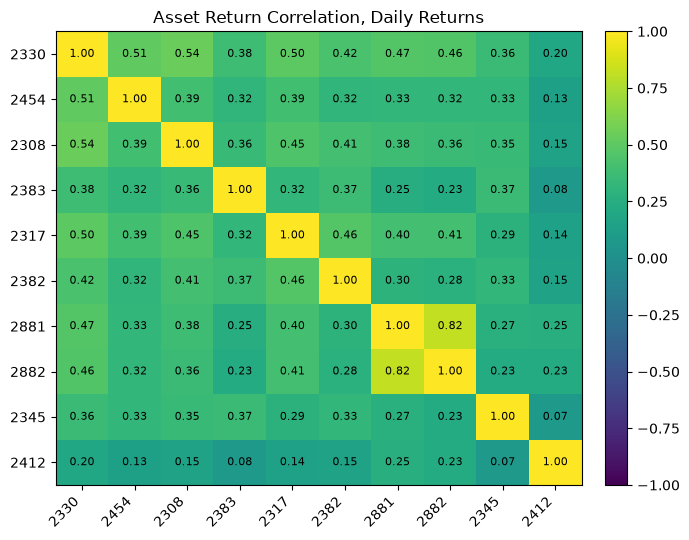

Asset return correlation table


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
2330,1.0000,0.5086,0.5426,0.3811,0.4993,0.4222,0.4660,0.4584,0.3622,0.2020
2454,0.5086,1.0000,0.3927,0.3178,0.3907,0.3171,0.3274,0.3212,0.3271,0.1337
2308,0.5426,0.3927,1.0000,0.3581,0.4473,0.4054,0.3799,0.3608,0.3476,0.1523
2383,0.3811,0.3178,0.3581,1.0000,0.3248,0.3704,0.2459,0.2275,0.3664,0.0795
2317,0.4993,0.3907,0.4473,0.3248,1.0000,0.4623,0.4017,0.4059,0.2889,0.1431
2382,0.4222,0.3171,0.4054,0.3704,0.4623,1.0000,0.2954,0.2777,0.3265,0.1528
2881,0.4660,0.3274,0.3799,0.2459,0.4017,0.2954,1.0000,0.8155,0.2666,0.2532
2882,0.4584,0.3212,0.3608,0.2275,0.4059,0.2777,0.8155,1.0000,0.2330,0.2337
2345,0.3622,0.3271,0.3476,0.3664,0.2889,0.3265,0.2666,0.2330,1.0000,0.0718
2412,0.2020,0.1337,0.1523,0.0795,0.1431,0.1528,0.2532,0.2337,0.0718,1.0000


In [6]:
asset_corr = asset_daily_returns_safe.loc[COMMON_BACKTEST_START:BACKTEST_END].corr()
plot_heatmap(asset_corr, "Asset Return Correlation, Daily Returns", "00_asset_correlation_heatmap.png", vmin=-1, vmax=1, annotate=True)
display_table(asset_corr, "Asset return correlation table", "00_asset_correlation_table.csv", decimals=4)

## 2. Factor Model

Factor Model 的目的是將股票報酬拆解成共同因子可以解釋的部分與個別股票自己的殘差部分。  
如果某些股票會受到相同市場因子的影響，例如大盤、半導體指數或匯率，則這些共同因子可以用來解釋股票之間的共變動結構。

對第 $i$ 檔股票而言，Factor Model 可以寫成：

$$
r_{i,t}
=
\alpha_i
+
\beta_{i,1} f_{1,t}
+
\beta_{i,2} f_{2,t}
+
\cdots
+
\beta_{i,K} f_{K,t}
+
\epsilon_{i,t}
$$

其中：

| 符號 | 意義 |
|---|---|
| $r_{i,t}$ | 第 $i$ 檔股票在時間 $t$ 的報酬率 |
| $\alpha_i$ | 第 $i$ 檔股票的截距項 |
| $f_{k,t}$ | 第 $k$ 個因子在時間 $t$ 的報酬率 |
| $\beta_{i,k}$ | 第 $i$ 檔股票對第 $k$ 個因子的敏感度，也就是 factor loading |
| $\epsilon_{i,t}$ | 模型無法解釋的殘差報酬 |

若用矩陣形式表示，模型可以寫成：

$$
X
=
\mathbf{1}\alpha^\top
+
F B^\top
+
E
$$

其中：

| 矩陣 | 意義 |
|---|---|
| $X$ | 股票報酬矩陣，列代表時間，欄代表股票 |
| $F$ | 因子報酬矩陣，列代表時間，欄代表因子 |
| $B$ | factor loading matrix，表示每檔股票對各因子的暴露程度 |
| $E$ | 殘差矩陣 |

本研究使用最近 36 個月的月報酬資料估計 factor loading。為了避免因子之間高度相關造成估計不穩定，程式中使用 ridge regression：

$$
\hat{\Theta}
=
(Z^\top Z + \lambda I)^{-1}Z^\top X
$$

其中 $Z$ 是包含截距項與因子報酬的 design matrix，$\lambda$ 是 ridge regularization 的強度。估計完成後，可以得到每檔股票的 factor loading matrix $B$ 與殘差 $E$。

Factor Model 的重要用途是建立 factor-implied covariance matrix。假設殘差之間彼此不相關，資產報酬 covariance matrix 可以寫成：

$$
\Sigma_{\text{FM}}
=
B\Sigma_f B^\top + D
$$

其中：

| 符號 | 意義 |
|---|---|
| $\Sigma_f$ | 因子報酬的 covariance matrix |
| $B \Sigma_f B^T$ | 由共同因子造成的系統性風險 |
| $D$ | 殘差變異數所形成的對角矩陣 |
| $\Sigma_{\text{FM}}$ | Factor Model 推導出的資產 covariance matrix |

後續的 Factor MinVar 策略會使用 $\Sigma_{\text{FM}}$ 取代單純由歷史報酬估計出的 empirical covariance matrix，藉此降低 covariance matrix 估計誤差，並希望得到更穩定的投資組合權重。

Factor covariance matrix, monthly returns


,TWII,SOX,USDTWD
TWII,0.003881,0.004825,-0.000364
SOX,0.004825,0.008508,-0.000788
USDTWD,-0.000364,-0.000788,0.000405


Factor Loading Matrix B


,TWII,SOX,USDTWD
2330,1.26,-0.02,0.17
2454,1.71,0.22,1.12
2308,1.88,0.16,1.49
2383,0.73,0.73,0.27
2317,2.00,-0.51,0.19
2382,-0.23,0.91,0.53
2881,0.22,0.09,0.09
2882,0.68,-0.15,-0.58
2345,1.10,-0.11,-0.39
2412,-0.01,0.04,-0.22


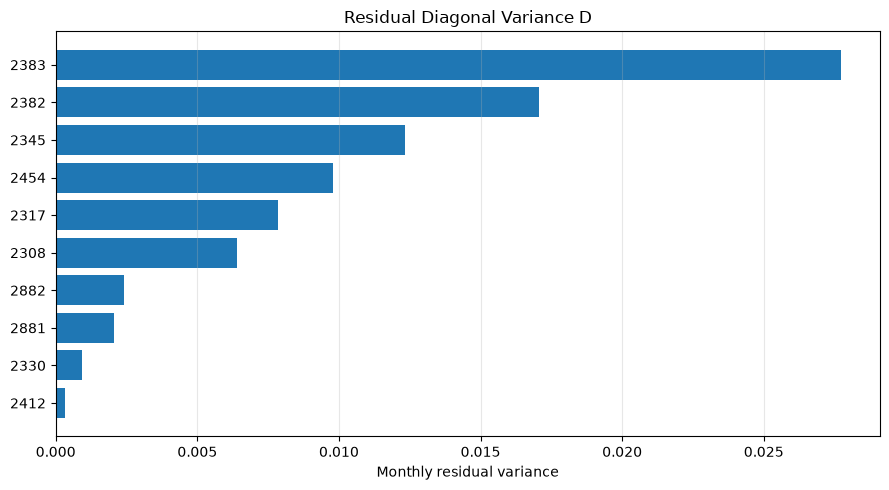

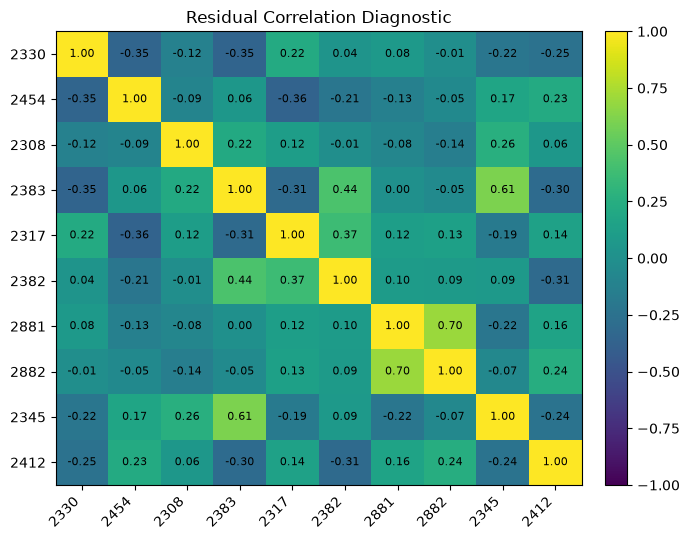

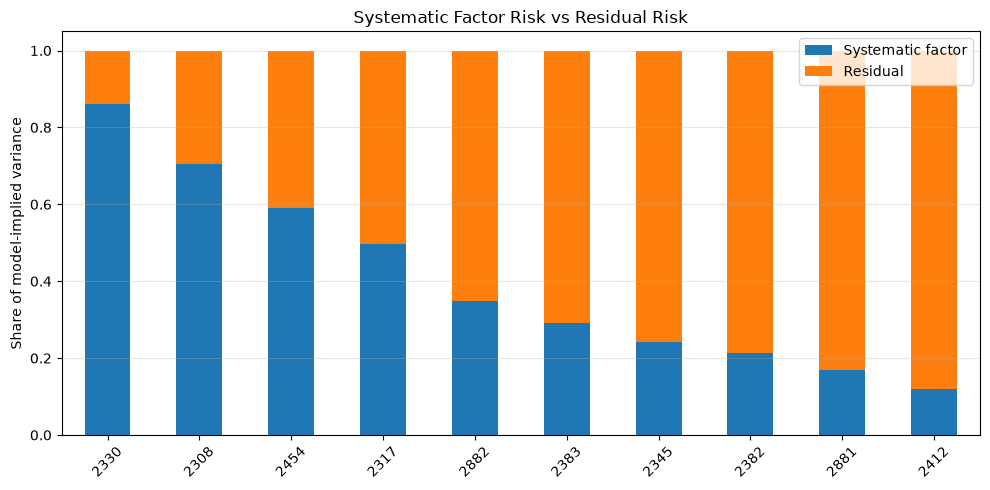

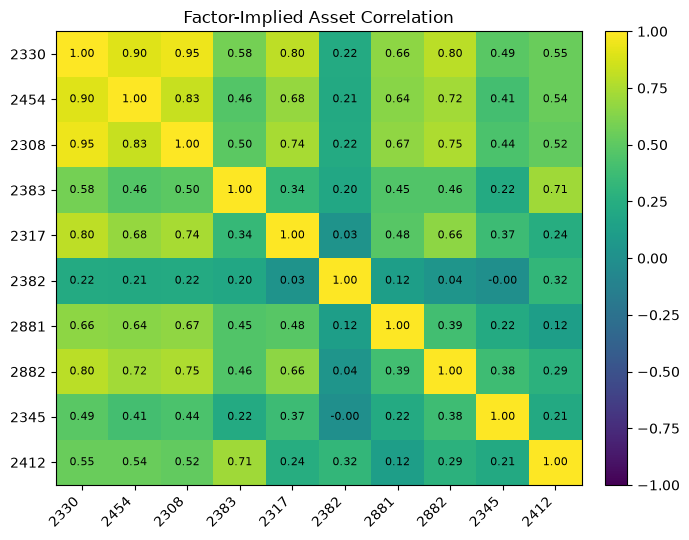

Factor loading matrix B


,TWII,SOX,USDTWD
2330,1.2561,-0.0249,0.1681
2454,1.7091,0.2211,1.1184
2308,1.8815,0.1596,1.4935
2383,0.7300,0.7347,0.2747
2317,1.9990,-0.5113,0.1860
2382,-0.2318,0.9070,0.5296
2881,0.2185,0.0896,0.0913
2882,0.6793,-0.1498,-0.5806
2345,1.0981,-0.1085,-0.3931
2412,-0.0080,0.0433,-0.2151


Residual diagonal variance D


,Monthly residual variance
2383,0.027717
2382,0.017072
2345,0.012343
2454,0.009798
2317,0.007862
2308,0.006412
2882,0.002412
2881,0.002067
2330,0.000914
2412,0.000333


Systematic vs residual risk


,Systematic factor,Residual
2330,0.8616,0.1384
2308,0.7052,0.2948
2454,0.5904,0.4096
2317,0.4969,0.5031
2882,0.3479,0.6521
2383,0.2915,0.7085
2345,0.2420,0.7580
2382,0.2132,0.7868
2881,0.1685,0.8315
2412,0.1189,0.8811


In [7]:
def estimate_factor_model(X_window, Z_window, ridge_alpha=1e-6):
    """
    X_window：股票月報酬資料
    Z_window：因子月報酬資料
    """
    X = X_window.copy().fillna(0.0)
    Z = Z_window.reindex(X.index).fillna(0.0)
    # 對齊資料
    X, Z = X.align(Z, join="inner", axis=0)
    # 常數項加上因子項
    Z_design = np.column_stack([np.ones(len(Z)), Z.values])
    penalty = np.eye(Z_design.shape[1]) * ridge_alpha
    penalty[0, 0] = 0.0
    # ridge regression：(Z'Z + λI)⁻¹Z'X
    coef = np.linalg.solve(Z_design.T @ Z_design + penalty, Z_design.T @ X.values)
    alpha = pd.Series(coef[0], index=X.columns, name="alpha")
    B = pd.DataFrame(coef[1:].T, index=X.columns, columns=Z.columns)
    fitted = pd.DataFrame(Z_design @ coef, index=X.index, columns=X.columns)
    eps = X - fitted
    return alpha, B, eps, Z

X_month = asset_monthly_returns.loc[:BACKTEST_END].dropna(how="all").tail(TRAIN_WINDOW_MONTHLY).fillna(0.0)
Z_month = factor_monthly_returns.reindex(X_month.index).fillna(0.0)
alpha_fm, B_fm, eps_fm, Z_fm = estimate_factor_model(X_month, Z_month)
# factor covariance
Sigma_f = Z_fm.cov()
# residual variance
resid_var = eps_fm.var(axis=0, ddof=1)
factor_cov_component = pd.DataFrame(B_fm.values @ Sigma_f.values @ B_fm.values.T, index=B_fm.index, columns=B_fm.index)
Sigma_fm = pd.DataFrame(factor_cov_component.values + np.diag(resid_var.values), index=B_fm.index, columns=B_fm.index)
factor_var = pd.Series(np.diag(factor_cov_component), index=B_fm.index, name="Systematic variance")
risk_share = pd.DataFrame({
    "Systematic factor": factor_var / (factor_var + resid_var),
    "Residual": resid_var / (factor_var + resid_var),
})

display_table(Sigma_f, "Factor covariance matrix, monthly returns", "factor_01_factor_covariance_table.csv", decimals=6)
display_table(B_fm, "Factor Loading Matrix B", "factor_02_factor_loadings_heatmap.png", decimals=2)
plot_bar(resid_var.sort_values(ascending=False), "Residual Diagonal Variance D", "Monthly residual variance", "factor_03_residual_diagonal_variance.png")
plot_heatmap(eps_fm.corr(), "Residual Correlation Diagnostic", "factor_04_residual_correlation_heatmap.png", vmin=-1, vmax=1, annotate=True)
fig, ax = plt.subplots(figsize=(10, 5))
risk_share.sort_values("Systematic factor", ascending=False).plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Systematic Factor Risk vs Residual Risk")
ax.set_ylabel("Share of model-implied variance")
ax.tick_params(axis="x", labelrotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
plot_heatmap(Sigma_fm.corr(), "Factor-Implied Asset Correlation", "factor_06_factor_implied_asset_correlation.png", vmin=-1, vmax=1, annotate=True)

display_table(B_fm, "Factor loading matrix B", "factor_02_factor_loadings_table.csv", decimals=4)
display_table(resid_var.to_frame("Monthly residual variance").sort_values("Monthly residual variance", ascending=False), "Residual diagonal variance D", "factor_03_residual_diagonal_variance_table.csv", decimals=6)
display_table(risk_share.sort_values("Systematic factor", ascending=False), "Systematic vs residual risk", "factor_05_systematic_vs_residual_risk.csv", decimals=4)

## 3. Mean-CVaR Strategy

### 3.1. Portfolio minimum CVaR allocation

CVaR strategy 使用 Conditional Value-at-Risk 作為風險衡量。

給定投資組合權重 $w$，第 $t$ 天投資組合報酬為：

$$
r_{p,t}
=
r_t^\top w
$$

投資組合損失定義為：

$$
L_t(w)
=
-r_t^\top w
$$

在信賴水準 $\alpha$ 下，CVaR 衡量的是超過 VaR 門檻後的平均損失：

$$
\operatorname{CVaR}_{\alpha}(w)
=
E\left[
L_t(w)
\mid
L_t(w) \geq \operatorname{VaR}_{\alpha}(w)
\right]
$$

使用 Rockafellar-Uryasev formulation，將最小化 CVaR 寫成線性規劃問題：

$$
\min_{w,\gamma,z}
\quad
\gamma
+
\frac{1}{(1-\alpha)T}
\sum_{t=1}^{T} z_t
$$

subject to：

$$
z_t \geq 0,
\quad
t=1,\ldots,T
$$

$$
z_t
\geq
-r_t^\top w - \gamma,
\quad
t=1,\ldots,T
$$

$$
\sum_{i=1}^{N} w_i = 1
$$

$$
0 \leq w_i \leq \text{WEIGHT\_CAP}
$$

其中：

| 符號 | 意義 |
|---|---|
| $w$ | 投資組合權重 |
| $\gamma$ | VaR 對應的決策變數 |
| $z_t$ | 第 $t$ 個情境中超過 VaR 的尾端損失 |
| $T$ | 訓練視窗中的歷史情境數 |
| $\alpha$ | CVaR 信賴水準，本研究使用 95% |

Asset VaR and CVaR


,VaR 95%,CVaR 95%
2345,0.055415,0.067733
2383,0.054330,0.066202
2308,0.036889,0.052394
2454,0.033190,0.043388
2317,0.030856,0.041028
2382,0.026836,0.036547
2330,0.022747,0.032016
2882,0.020689,0.031240
2881,0.016366,0.023416
2412,0.010887,0.013407


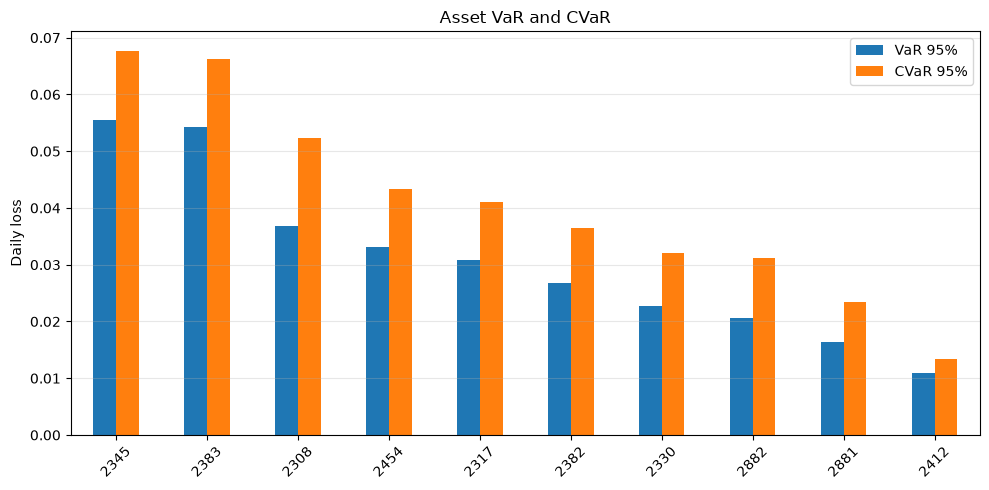

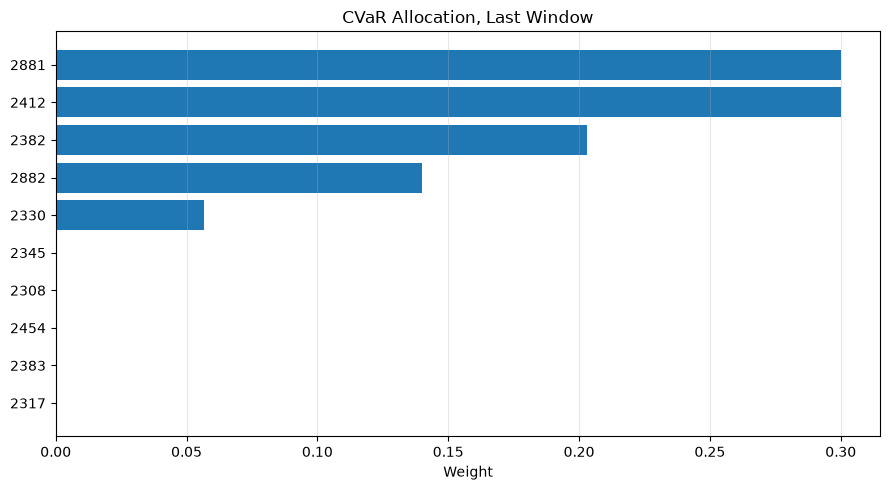

CVaR allocation, last window


,CVaR allocation weight
2881,0.3000
2412,0.3000
2382,0.2030
2882,0.1402
2330,0.0568
2454,0.0000
2317,0.0000
2383,0.0000
2308,0.0000
2345,0.0000


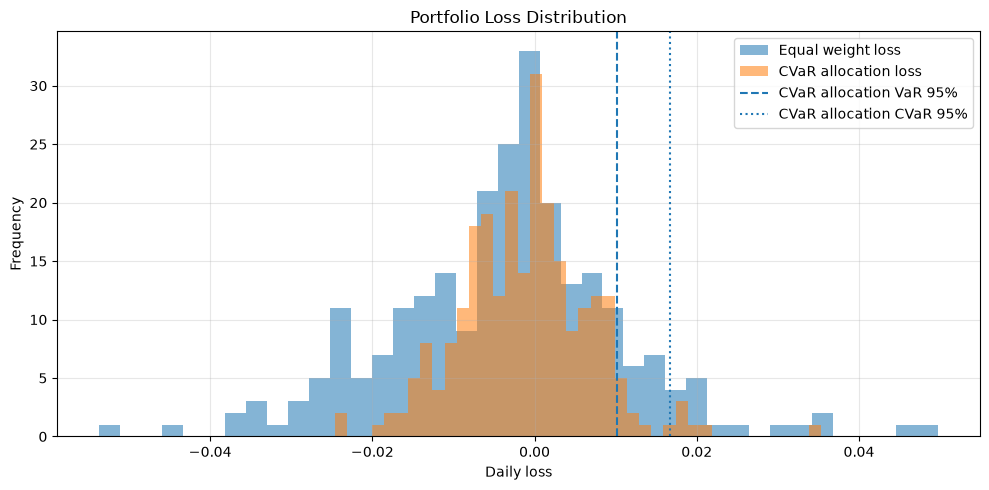

Rolling CVaR allocation summary


,Mean weight,Latest weight,Min weight,Max weight,Share of rebalances at cap,Share of rebalances held
2412,0.3000,0.3000,0.3,0.3000,0.8548,1.0000
2881,0.1521,0.3000,0.0,0.3000,0.2742,0.8226
2882,0.1283,0.0000,0.0,0.3000,0.1452,0.7339
2382,0.1202,0.2771,0.0,0.3000,0.1210,0.7742
2317,0.0904,0.0000,0.0,0.3000,0.0887,0.5484
2330,0.0793,0.1122,0.0,0.3000,0.0806,0.5565
2308,0.0490,0.0107,0.0,0.2278,0.0000,0.7097
2383,0.0303,0.0000,0.0,0.2838,0.0000,0.5081
2345,0.0279,0.0000,0.0,0.1404,0.0000,0.6532
2454,0.0226,0.0000,0.0,0.1777,0.0000,0.4355


Rolling CVaR allocation weights, full history


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
2016-05-23,0.0000,0.0,0.1393,0.0116,0.2734,0.1873,0.0000,0.0000,0.0884,0.3
2016-06-21,0.0118,0.0,0.1626,0.0757,0.2353,0.0792,0.0122,0.0000,0.1232,0.3
2016-07-20,0.0318,0.0,0.0342,0.0787,0.3000,0.1818,0.0000,0.0000,0.0734,0.3
2016-08-18,0.0257,0.0,0.0776,0.1314,0.2941,0.0805,0.0000,0.0000,0.0907,0.3
2016-09-16,0.0911,0.0,0.0148,0.1295,0.2895,0.1170,0.0000,0.0000,0.0582,0.3
2016-10-17,0.0911,0.0,0.0148,0.1295,0.2895,0.1170,0.0000,0.0000,0.0582,0.3
2016-11-15,0.0612,0.0,0.0543,0.0515,0.2551,0.0000,0.2523,0.0000,0.0257,0.3
2016-12-14,0.0287,0.0,0.0735,0.2838,0.1898,0.0000,0.0895,0.0347,0.0000,0.3
2017-01-12,0.0000,0.0,0.1010,0.1118,0.1816,0.0000,0.0000,0.2322,0.0735,0.3
2017-02-10,0.0000,0.0,0.1224,0.0944,0.2253,0.0000,0.0000,0.2219,0.0361,0.3


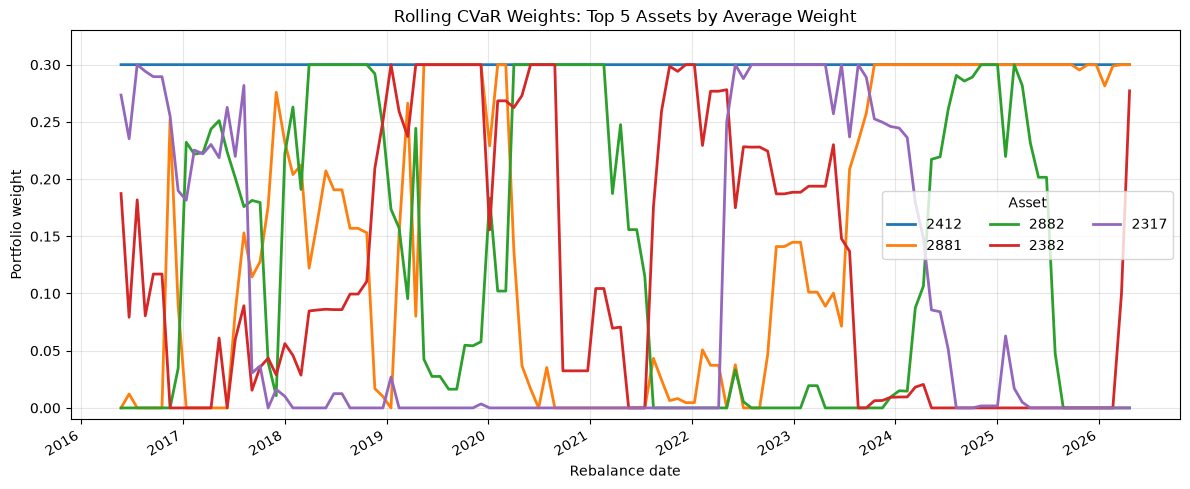

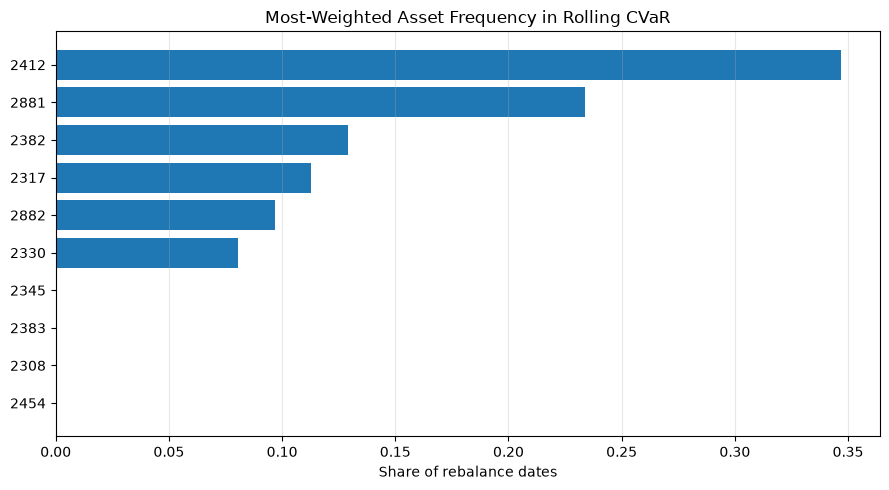

In [8]:
from pypfopt.efficient_frontier import EfficientCVaR
from pypfopt import expected_returns

def strategy_cvar(train_returns, alpha=ALPHA_CVAR, cap=WEIGHT_CAP):
    """
    找出特定權重 w，使得投資組合的 CVaR 最小
    """
    R = clean_training_returns(train_returns)

    if R.shape[1] == 0:
        return pd.Series(dtype=float)

    try:
        mu = expected_returns.mean_historical_return(
            R,
            returns_data=True,
            frequency=252,
        )

        ef = EfficientCVaR(
            expected_returns=mu,
            returns=R,
            beta=alpha,
            weight_bounds=(0, cap),
        )

        ef.min_cvar()
        weights = ef.clean_weights()

        w = pd.Series(weights, dtype=float).reindex(R.columns).fillna(0.0)

    except Exception:
        w = equal_weight(R.columns, cap=cap)

    return normalize_long_only_cap(w, cap=cap)


def var_cvar_loss(ret, alpha=ALPHA_CVAR):
    """
    計算 VaR、CVaR
    """
    loss = -pd.Series(ret).dropna()
    var = float(np.quantile(loss, alpha))
    cvar = float(loss[loss >= var].mean())
    return var, cvar

last_R = asset_daily_returns_safe.loc[:BACKTEST_END].tail(TRAIN_WINDOW_DAILY)
asset_var_cvar = pd.DataFrame({col: var_cvar_loss(last_R[col], ALPHA_CVAR) for col in last_R.columns}, index=["VaR 95%", "CVaR 95%"]).T
asset_var_cvar_table = asset_var_cvar.sort_values("CVaR 95%", ascending=False)
display_table(asset_var_cvar_table, "Asset VaR and CVaR", "cvar_01_asset_var_cvar_ranking_table.csv", decimals=6)
fig, ax = plt.subplots(figsize=(10, 5))
asset_var_cvar_table.plot(kind="bar", ax=ax)
ax.set_title("Asset VaR and CVaR")
ax.set_ylabel("Daily loss")
ax.tick_params(axis="x", labelrotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

w_cvar_last = strategy_cvar(last_R)
plot_bar(w_cvar_last.sort_values(ascending=False), "CVaR Allocation, Last Window", "Weight", "cvar_02_last_window_cvar_weights.png")
display_table(w_cvar_last.sort_values(ascending=False).to_frame("CVaR allocation weight"), "CVaR allocation, last window", "cvar_02_last_window_cvar_weights_table.csv", decimals=4)

w_equal_last = pd.Series(1.0 / len(last_R.columns), index=last_R.columns)
loss_equal = -(last_R @ w_equal_last)
loss_cvar = -(last_R @ w_cvar_last)
var_cvar_port, cvar_cvar_port = var_cvar_loss(last_R @ w_cvar_last, ALPHA_CVAR)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(loss_equal, bins=40, alpha=0.55, label="Equal weight loss")
ax.hist(loss_cvar, bins=40, alpha=0.55, label="CVaR allocation loss")
ax.axvline(var_cvar_port, linestyle="--", label="CVaR allocation VaR 95%")
ax.axvline(cvar_cvar_port, linestyle=":", label="CVaR allocation CVaR 95%")
ax.set_title("Portfolio Loss Distribution")
ax.set_xlabel("Daily loss")
ax.set_ylabel("Frequency")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

rolling_cvar_weights = []
for t in range(TRAIN_WINDOW_DAILY, len(asset_daily_returns_safe), REBAL_FREQ_DAILY):
    date = asset_daily_returns_safe.index[t]
    if date < pd.Timestamp(COMMON_BACKTEST_START) or date > pd.Timestamp(BACKTEST_END):
        continue
    w = strategy_cvar(asset_daily_returns_safe.iloc[t - TRAIN_WINDOW_DAILY:t])
    w.name = date
    rolling_cvar_weights.append(w)
rolling_cvar_weights = pd.DataFrame(rolling_cvar_weights)
rolling_cvar_summary = pd.DataFrame({
    "Mean weight": rolling_cvar_weights.mean(),
    "Latest weight": rolling_cvar_weights.iloc[-1],
    "Min weight": rolling_cvar_weights.min(),
    "Max weight": rolling_cvar_weights.max(),
    "Share of rebalances at cap": (rolling_cvar_weights >= WEIGHT_CAP - 1e-8).mean(),
    "Share of rebalances held": (rolling_cvar_weights > 1e-8).mean(),
}).sort_values("Mean weight", ascending=False)
display_table(rolling_cvar_summary, "Rolling CVaR allocation summary", "cvar_04_rolling_weights_summary_table.csv", decimals=4)
display_table(rolling_cvar_weights, "Rolling CVaR allocation weights, full history", "cvar_04_rolling_weights_table.csv", decimals=4, max_rows=12)

top_assets = rolling_cvar_summary.head(5).index.tolist()
fig, ax = plt.subplots(figsize=(12, 5))
rolling_cvar_weights[top_assets].plot(ax=ax, linewidth=2)
ax.set_title("Rolling CVaR Weights: Top 5 Assets by Average Weight")
ax.set_ylabel("Portfolio weight")
ax.set_xlabel("Rebalance date")
ax.set_ylim(-0.01, WEIGHT_CAP + 0.03)
ax.grid(True, alpha=0.3)
ax.legend(title="Asset", ncol=3)
plt.tight_layout()
plt.show()

top_asset_each_rebalance = rolling_cvar_weights.idxmax(axis=1)
top_asset_frequency = top_asset_each_rebalance.value_counts(normalize=True).reindex(rolling_cvar_weights.columns).fillna(0.0).sort_values()
plot_bar(top_asset_frequency, "Most-Weighted Asset Frequency in Rolling CVaR", "Share of rebalance dates", "cvar_04_top_asset_frequency.png", horizontal=True)

### 3.2. Mean-CVaR Efficient Frontier

使用最後一個 training window 建立 Mean-CVaR efficient frontier。  
前一個 CVaR strategy 只求出一個 minimum-CVaR portfolio；這裡則是在不同目標報酬下重複求解 CVaR optimization，觀察報酬與尾端風險之間的取捨。

首先求出 minimum-CVaR portfolio：

$$
\min_w
\quad
\operatorname{CVaR}_{\alpha}(w)
$$

subject to：

$$
\sum_{i=1}^{N}w_i=1
$$

$$
0 \leq w_i \leq \text{WEIGHT\_CAP}
$$

這個點是 frontier 最左側的低尾端風險組合。

接著設定一系列的 target return。對每一個目標報酬 $\rho$，解下列問題：

$$
\min_w
\quad
\operatorname{CVaR}_{\alpha}(w)
$$

subject to：

$$
E[r_p] \geq \rho
$$

$$
\sum_{i=1}^{N}w_i=1
$$

$$
0 \leq w_i \leq \text{WEIGHT\_CAP}
$$

當 $\rho$ 越高，投資組合通常必須承擔較高的尾端風險，因此 frontier 會呈現 expected return 與 CVaR loss 之間的 tradeoff。

這個 chunk 會輸出三個主要結果：

| 輸出 | 解讀 |
|---|---|
| Mean-CVaR frontier plot | 藍線代表不同 target return 下的 CVaR 最佳投資組合 |
| Min-CVaR point | 紅點代表不要求目標報酬時的最低 CVaR 投資組合 |
| Frontier weights heatmap | 顯示從低 CVaR 到高 target return 的過程中，權重的變化 |

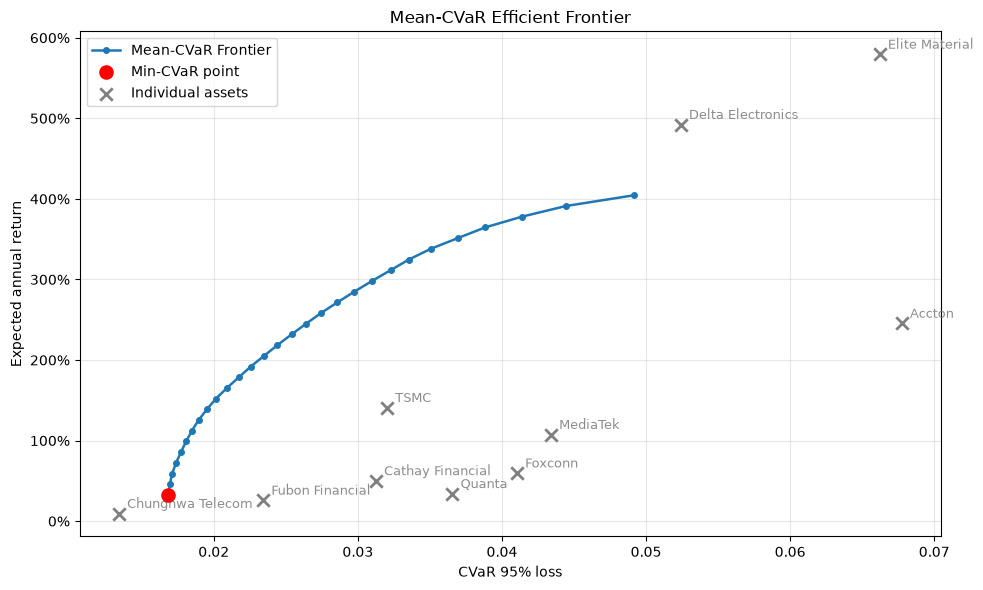

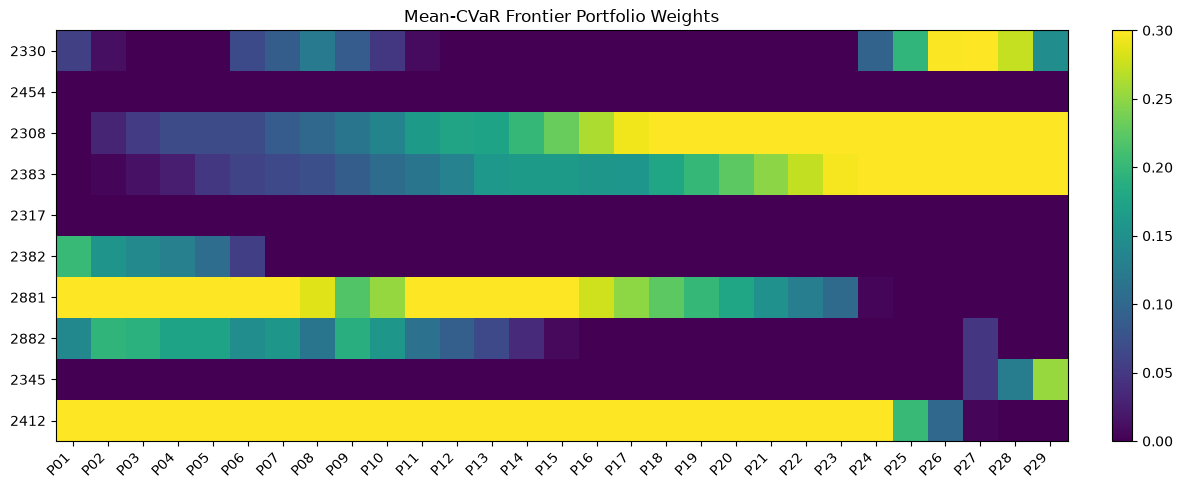

Mean-CVaR efficient frontier points


,Expected Annual Return,CVaR 95% Loss
0,0.326009,0.016851
1,0.458808,0.016949
2,0.591608,0.017115
3,0.724407,0.017384
4,0.857207,0.017725
5,0.990007,0.018082
6,1.122806,0.018481
7,1.255606,0.018951
8,1.388405,0.019524
9,1.521205,0.020156


Mean-CVaR frontier portfolio weights


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
P01,0.0568,0.0,0.0000,0.0000,0.0,0.2030,0.3000,0.1402,0.0000,0.3000
P02,0.0118,0.0,0.0315,0.0051,0.0,0.1554,0.3000,0.1963,0.0000,0.3000
P03,0.0000,0.0,0.0524,0.0143,0.0,0.1412,0.3000,0.1921,0.0000,0.3000
P04,0.0000,0.0,0.0695,0.0248,0.0,0.1311,0.3000,0.1746,0.0000,0.3000
P05,0.0000,0.0,0.0703,0.0485,0.0,0.1068,0.3000,0.1744,0.0000,0.3000
P06,0.0674,0.0,0.0692,0.0613,0.0,0.0551,0.3000,0.1469,0.0000,0.3000
P07,0.0884,0.0,0.0875,0.0659,0.0,0.0000,0.3000,0.1582,0.0000,0.3000
P08,0.1252,0.0,0.1006,0.0730,0.0,0.0000,0.2848,0.1164,0.0000,0.3000
P09,0.0872,0.0,0.1161,0.0887,0.0,0.0000,0.2183,0.1897,0.0000,0.3000
P10,0.0484,0.0,0.1349,0.1062,0.0,0.0000,0.2521,0.1584,0.0000,0.3000


In [9]:
last_train = last_R.copy()

mu_last = expected_returns.mean_historical_return(
    last_train,
    returns_data=True,
    frequency=252,
)

frontier_ret = []
frontier_cvar = []
frontier_weights = []

# 建立 min-CVaR 投資組合
ef0 = EfficientCVaR(
    expected_returns=mu_last,
    returns=last_train,
    beta=ALPHA_CVAR,
    weight_bounds=(0, WEIGHT_CAP),
)

ef0.min_cvar()
r0, c0 = ef0.portfolio_performance()

w0 = pd.Series(
    ef0.clean_weights(),
    dtype=float,
).reindex(last_train.columns).fillna(0.0)

# 建立 frontier 的 target returns
target_start = float(r0)
target_end = float(mu_last.max()) * 0.95

targets = np.linspace(target_start, target_end, 40)

# 對每一個 target returns，找出對應的投資組合
for target in targets:
    try:
        ef_f = EfficientCVaR(
            expected_returns=mu_last,
            returns=last_train,
            beta=ALPHA_CVAR,
            weight_bounds=(0, WEIGHT_CAP),
        )

        ef_f.efficient_return(float(target))
        r_f, c_f = ef_f.portfolio_performance()

        w_f = pd.Series(
            ef_f.clean_weights(),
            dtype=float,
        ).reindex(last_train.columns).fillna(0.0)

        frontier_ret.append(float(r_f))
        frontier_cvar.append(float(c_f))
        frontier_weights.append(w_f)

    except Exception:
        pass

frontier_points = pd.DataFrame({
    "Expected Annual Return": frontier_ret,
    "CVaR 95% Loss": frontier_cvar,
})

frontier_weights = pd.DataFrame(frontier_weights)

if len(frontier_weights) > 0:
    frontier_weights = frontier_weights.reindex(columns=last_train.columns).fillna(0.0)
    frontier_weights.index = [f"P{i:02d}" for i in range(1, len(frontier_weights) + 1)]

# 建立單一資產的位置
asset_points = []

for col in last_train.columns:
    var_i, cvar_i = var_cvar_loss(last_train[col], ALPHA_CVAR)

    if "ASSET_NAMES" in globals():
        label = ASSET_NAMES.get(col, col)
    else:
        label = col

    asset_points.append({
        "Asset": label,
        "Ticker": col,
        "Expected Annual Return": float(mu_last[col]),
        "VaR 95% Loss": float(var_i),
        "CVaR 95% Loss": float(cvar_i),
    })

asset_points = pd.DataFrame(asset_points)

# 效率前緣
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    frontier_points["CVaR 95% Loss"],
    frontier_points["Expected Annual Return"],
    marker="o",
    linewidth=1.8,
    markersize=4,
    label="Mean-CVaR Frontier",
)

ax.scatter(
    [c0],
    [r0],
    s=90,
    color="red",
    label="Min-CVaR point",
    zorder=5,
)

ax.scatter(
    asset_points["CVaR 95% Loss"],
    asset_points["Expected Annual Return"],
    marker="x",
    s=80,
    color="gray",
    linewidths=2,
    label="Individual assets",
    zorder=4,
)

for _, row in asset_points.iterrows():
    ax.annotate(
        row["Asset"],
        xy=(row["CVaR 95% Loss"], row["Expected Annual Return"]),
        xytext=(6, 4),
        textcoords="offset points",
        fontsize=9,
        color="gray",
        alpha=0.9,
    )

ax.set_title("Mean-CVaR Efficient Frontier")
ax.set_xlabel("CVaR 95% loss")
ax.set_ylabel("Expected annual return")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 展示權重
if len(frontier_weights) > 0:
    plot_heatmap(
        frontier_weights.T,
        "Mean-CVaR Frontier Portfolio Weights",
        "cvar_06_efficient_frontier_weights_heatmap.png",
        vmin=0,
        vmax=WEIGHT_CAP,
        figsize=(12, 5),
    )

    display_table(
        frontier_points,
        "Mean-CVaR efficient frontier points",
        "cvar_05_efficient_frontier_table.csv",
        decimals=6,
    )

    display_table(
        frontier_weights,
        "Mean-CVaR frontier portfolio weights",
        "cvar_06_efficient_frontier_weights_table.csv",
        decimals=4,
        max_rows=40,
    )

## 4. HRP 1/n portfolio

HRP 1/n portfolio 保留 HRP 的階層式分群流程，但不再使用 cluster variance 決定左右 cluster 的資金比例，而是每次分裂時將父 cluster 的資金平均分成兩半。因此，它可以視為介於 Equal Weight 與標準 HRP 之間的階層式分散配置方法。

標準 HRP 在左右 cluster 之間的配置比例為：

$$
\alpha_L
=
\frac{\sigma_R^2}{\sigma_L^2+\sigma_R^2},
\qquad
\alpha_R
=
1-\alpha_L
$$

其中 $\sigma_L^2$ 與 $\sigma_R^2$ 分別是左右 cluster 的風險。

HRP 1/n 則改成：

$$
\alpha_L
=
\alpha_R
=
\frac{1}{2}
$$

也就是只使用 hierarchical clustering 決定資產排序與切分結構，但不使用 covariance matrix 的 cluster risk 來偏向低風險 cluster。這樣的設計可以用來檢查：HRP 的績效來源究竟主要來自 hierarchical clustering 本身，還是來自根據 cluster variance 做出的風險配置。

HRP 1/n 與 HRP Pearson 使用相同的 Pearson correlation distance：

$$
d_{ij}
=
\sqrt{\frac{1-\rho_{ij}}{2}}
$$

差別在於 recursive bisection 時，HRP Pearson 使用 cluster variance 決定左右權重，而 HRP 1/n 每次都平均切分權重。最後仍會套用 long-only、full-investment 與單一資產權重上限 `WEIGHT_CAP`。


Single-window HRP 1/n weight comparison


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
Equal Weight,0.1000,0.1000,0.1000,0.1000,0.1000,0.1000,0.100,0.1000,0.1000,0.100
HRP 1/n,0.1250,0.0625,0.1250,0.0625,0.0625,0.1250,0.125,0.1250,0.0625,0.125
HRP Pearson,0.0456,0.0415,0.0156,0.0065,0.0678,0.0453,0.300,0.1704,0.0073,0.300


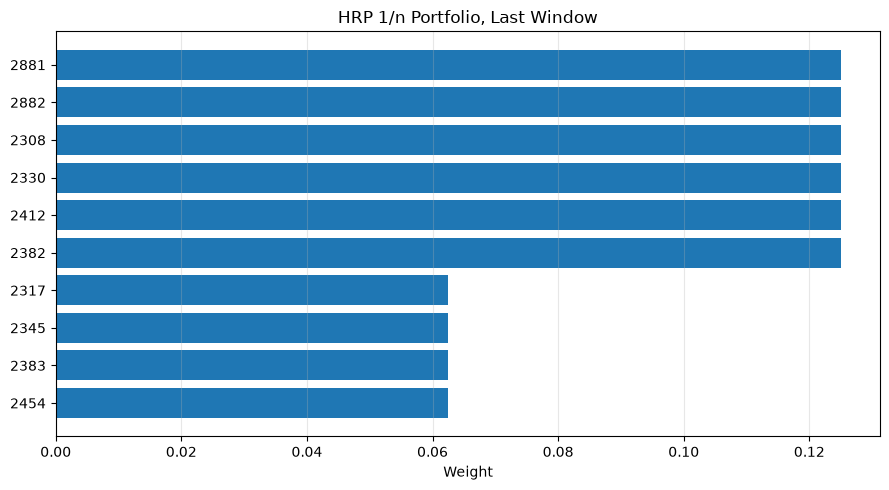

In [10]:
def get_quasi_diag(link):
    link = link.astype(int)
    sort_ix = pd.Series([link[-1, 0], link[-1, 1]])
    num_items = link[-1, 3]
    while sort_ix.max() >= num_items:
        sort_ix.index = range(0, sort_ix.shape[0] * 2, 2)
        df0 = sort_ix[sort_ix >= num_items]
        i = df0.index
        j = df0.values - num_items
        sort_ix.loc[i] = link[j, 0]
        df1 = pd.Series(link[j, 1], index=i + 1)
        sort_ix = pd.concat([sort_ix, df1]).sort_index()
        sort_ix.index = range(sort_ix.shape[0])
    return sort_ix.tolist()


def cluster_variance(cov, cluster_items):
    cov_slice = cov.loc[cluster_items, cluster_items]
    diag = np.diag(cov_slice).astype(float)
    diag = np.where(diag <= 0, np.nan, diag)
    ivp = 1.0 / diag
    ivp = np.nan_to_num(ivp, nan=0.0, posinf=0.0, neginf=0.0)
    ivp = np.repeat(1.0 / len(cluster_items), len(cluster_items)) if ivp.sum() <= 0 else ivp / ivp.sum()
    return float(ivp @ cov_slice.values @ ivp)


def bounded_split_mass(total_mass, alpha, n_left, n_right, cap=WEIGHT_CAP):
    lower_left = max(0.0, total_mass - cap * n_right)
    upper_left = min(total_mass, cap * n_left)
    if lower_left > upper_left + 1e-12:
        return total_mass * n_left / (n_left + n_right)
    return float(np.clip(total_mass * float(alpha), lower_left, upper_left))

def recursive_bisection_with_cap(cov, sorted_items, cap=WEIGHT_CAP):
    final_w = pd.Series(0.0, index=sorted_items, dtype=float)
    clusters = [(list(sorted_items), 1.0)]
    while clusters:
        next_clusters = []
        for cluster, mass in clusters:
            if len(cluster) == 1:
                final_w.loc[cluster[0]] += mass
                continue
            split = len(cluster) // 2
            c1, c2 = cluster[:split], cluster[split:]
            var1, var2 = cluster_variance(cov, c1), cluster_variance(cov, c2)
            alpha = 0.5 if (not np.isfinite(var1 + var2) or var1 + var2 <= 0) else 1.0 - var1 / (var1 + var2)
            mass1 = bounded_split_mass(mass, alpha, len(c1), len(c2), cap=cap)
            next_clusters.append((c1, mass1))
            next_clusters.append((c2, mass - mass1))
        clusters = next_clusters
    return normalize_long_only_cap(final_w, cap=cap)

def hrp_from_cov_corr(cov, corr, cap=WEIGHT_CAP, linkage_method="single"):
    cols = list(cov.columns)
    cov = positive_semi_definite(cov)
    corr = pd.DataFrame(corr, index=cols, columns=cols).astype(float).clip(-0.999, 0.999)
    corr_values = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_values, 1.0)
    corr = pd.DataFrame(corr_values, index=cols, columns=cols)
    d = np.sqrt(0.5 * (1.0 - corr)).clip(lower=0.0)
    d_values = d.to_numpy(copy=True)
    np.fill_diagonal(d_values, 0.0)
    link = linkage(squareform(d_values, checks=False), method=linkage_method)
    sort_ix = get_quasi_diag(link)
    sorted_items = corr.index[sort_ix].tolist()
    return recursive_bisection_with_cap(cov, sorted_items, cap=cap).reindex(cols).fillna(0.0)

def strategy_hrp_pearson(train_returns, cap=WEIGHT_CAP):
    R = clean_training_returns(train_returns)
    cov = R.cov()
    corr = R.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-0.999, 0.999)
    return hrp_from_cov_corr(cov, corr, cap=cap)

def recursive_one_over_n_bisection_with_cap(sorted_items, cap=WEIGHT_CAP):

    final_w = pd.Series(0.0, index=sorted_items, dtype=float)
    clusters = [(list(sorted_items), 1.0)]

    while clusters:
        next_clusters = []

        for cluster, mass in clusters:
            if len(cluster) == 1:
                final_w.loc[cluster[0]] += mass
                continue

            split = len(cluster) // 2
            c1, c2 = cluster[:split], cluster[split:]

            # HRP 1/n: split every parent cluster equally.
            # bounded_split_mass is still used to respect the future cap feasibility.
            mass1 = bounded_split_mass(
                total_mass=mass,
                alpha=0.5,
                n_left=len(c1),
                n_right=len(c2),
                cap=cap,
            )

            next_clusters.append((c1, mass1))
            next_clusters.append((c2, mass - mass1))

        clusters = next_clusters

    return normalize_long_only_cap(final_w, cap=cap)


def hrp_one_over_n_from_corr(corr, cap=WEIGHT_CAP, linkage_method="single"):

    corr = pd.DataFrame(corr).astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    cols = list(corr.columns)

    corr = corr.reindex(index=cols, columns=cols).clip(-0.999, 0.999)
    corr_values = corr.to_numpy(copy=True)
    np.fill_diagonal(corr_values, 1.0)
    corr = pd.DataFrame(corr_values, index=cols, columns=cols)

    dist = np.sqrt(0.5 * (1.0 - corr)).clip(lower=0.0)
    dist_values = dist.to_numpy(copy=True)
    np.fill_diagonal(dist_values, 0.0)

    link = linkage(squareform(dist_values, checks=False), method=linkage_method)
    sort_ix = get_quasi_diag(link)
    sorted_items = corr.index[sort_ix].tolist()

    w = recursive_one_over_n_bisection_with_cap(sorted_items, cap=cap)
    return w.reindex(cols).fillna(0.0), link, sorted_items


def strategy_hrp_one_over_n(train_returns, cap=WEIGHT_CAP):
    R = clean_training_returns(train_returns)
    corr = R.corr().replace([np.inf, -np.inf], np.nan).fillna(0.0).clip(-0.999, 0.999)
    w, _, _ = hrp_one_over_n_from_corr(corr, cap=cap)
    return normalize_long_only_cap(w, cap=cap)


w_hrp_one_over_n_last = strategy_hrp_one_over_n(last_R)

hrp_one_over_n_last_compare = pd.DataFrame({
    "Equal Weight": equal_weight(last_R.columns),
    "HRP 1/n": w_hrp_one_over_n_last,
    "HRP Pearson": strategy_hrp_pearson(last_R),
}).T

display_table(
    hrp_one_over_n_last_compare,
    "Single-window HRP 1/n weight comparison",
    "hrp_1n_single_window_weights_table.csv",
    decimals=4,
)

plot_bar(
    w_hrp_one_over_n_last.sort_values(ascending=False),
    "HRP 1/n Portfolio, Last Window",
    "Weight",
    "hrp_1n_last_window_weights.png",
    horizontal=True,
)


## 5. Hierarchical Risk Parity with Pearson and DCCA correlation

Hierarchical Risk Parity 先用相關性建立資產的階層結構，再根據 cluster risk 進行遞迴配置。

HRP 的流程可分成三步：

1. 根據 correlation matrix 建立距離矩陣。
2. 使用 hierarchical clustering 排列資產。
3. 使用 recursive bisection 在左右 cluster 之間分配權重。

#### (1) Correlation distance

HRP 會將 correlation 轉成距離：

$$
d_{ij}
=
\sqrt{
\frac{1-\rho_{ij}}{2}
}
$$

當兩檔股票高度正相關時，$\rho_{ij}$ 接近 1，因此距離接近 0；當兩檔股票相關性低或負相關時，距離較大。

#### (2) Cluster variance

對某一個 cluster $C$，程式先在 cluster 內使用 inverse variance portfolio 作為局部權重，再估計 cluster variance：

$$
\sigma_C^2
=
w_C^\top \Sigma_C w_C
$$

其中 $\Sigma_C$ 是 cluster 內資產的 covariance matrix。

#### (3) Recursive bisection

當一個 cluster 被切成左 cluster 和右 cluster 時，HRP 會將更多權重分配給風險較低的 cluster。若左 cluster variance 為 $\sigma_L^2$，右 cluster variance 為 $\sigma_R^2$，則左側權重比例可以表示為：

$$
\alpha_L
=
\frac{\sigma_R^2}
{\sigma_L^2+\sigma_R^2}
$$

右側權重比例為：

$$
\alpha_R
=
1-\alpha_L
$$

加入 `WEIGHT_CAP` 限制，因此在 split mass 時會避免任一 cluster 未來分配後導致單一股票超過上限。

#### (4) Pearson HRP 與 DCCA HRP

比較兩種 HRP correlation input：

| 策略 | Correlation input |
|---|---|
| HRP Pearson | 使用日報酬 Pearson correlation |
| HRP DCCA | 使用價格序列的 Detrended Cross-Correlation Analysis |

DCCA 的目的是在有趨勢或非平穩價格序列中，衡量兩個序列在 detrended fluctuation 後的共變動。概念上可寫成：

$$
\rho_{\text{DCCA}}(s)
=
\frac{F^2_{xy}(s)}
{F_{xx}(s)F_{yy}(s)}
$$

其中 $s$ 是 box size，$F_{xy}$ 是兩序列的 detrended covariance fluctuation，$F_{xx}$ 與 $F_{yy}$ 是各自的 detrended fluctuation。

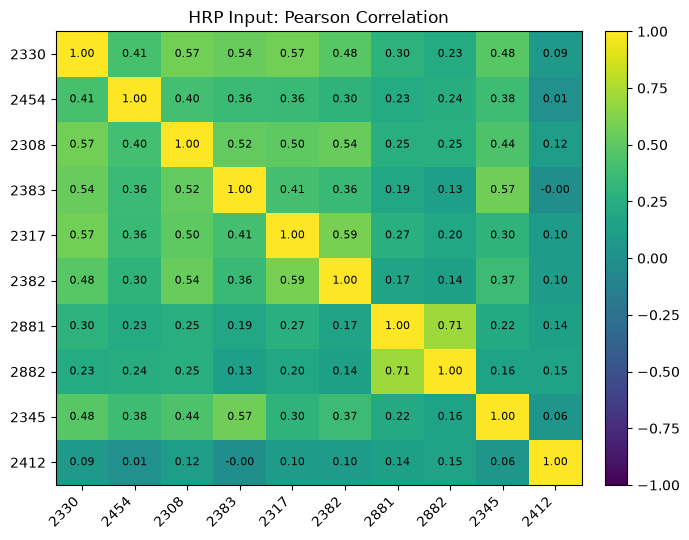

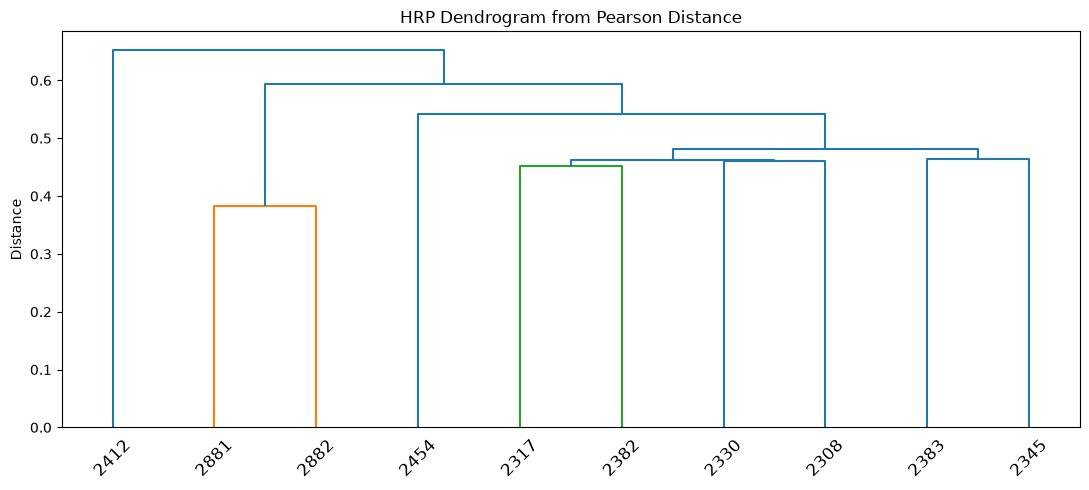

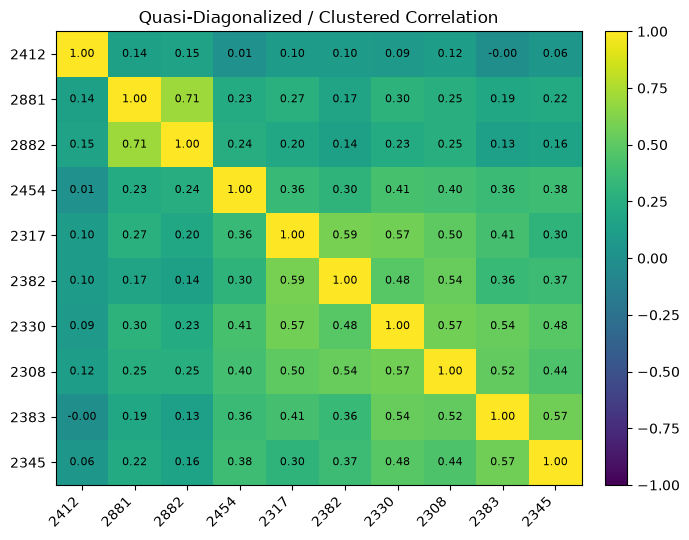

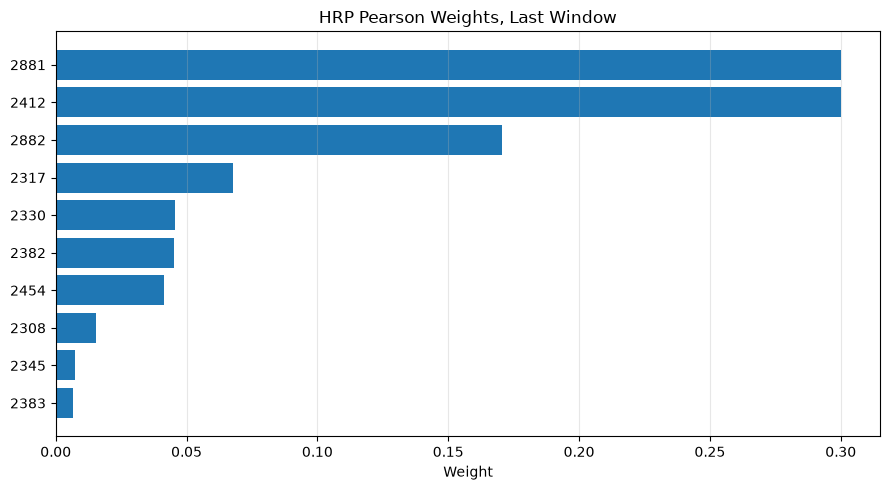

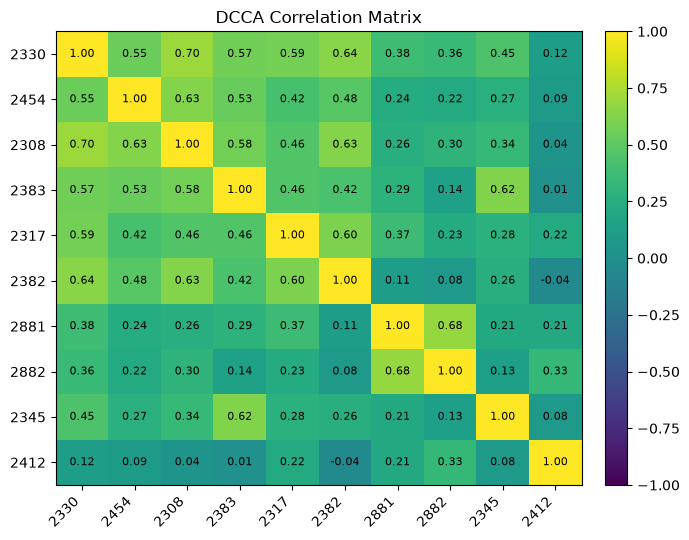

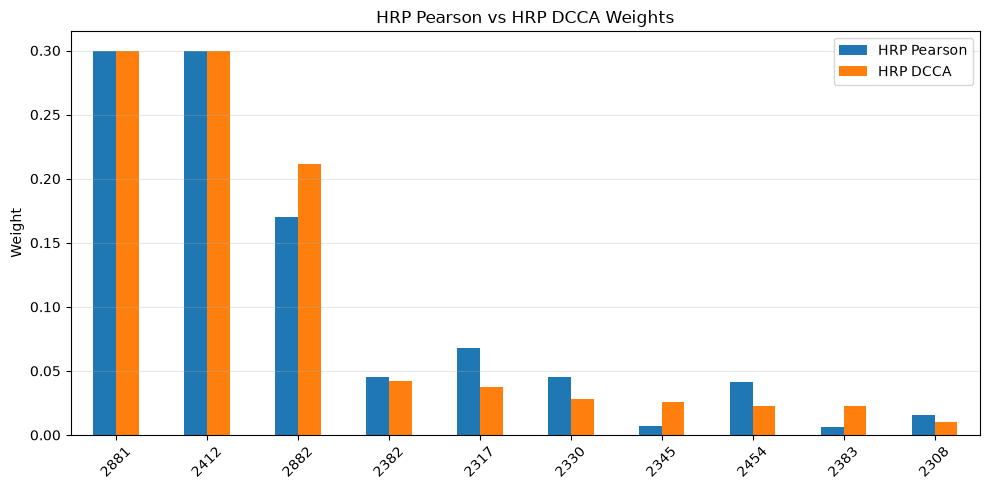

HRP Pearson vs HRP DCCA weights


,HRP Pearson,HRP DCCA
2881,0.3000,0.3000
2412,0.3000,0.3000
2882,0.1704,0.2111
2382,0.0453,0.0419
2317,0.0678,0.0375
2330,0.0456,0.0280
2345,0.0073,0.0255
2454,0.0415,0.0229
2383,0.0065,0.0229
2308,0.0156,0.0102


In [11]:
def dcca_correlation_matrix_fast(price_window, box_size=20):
    px = price_window.copy().ffill()
    log_ret = np.log(px).diff().dropna(how="all").replace([np.inf, -np.inf], np.nan).fillna(0.0)
    tickers = log_ret.columns.tolist()
    X = log_ret.to_numpy(dtype=float, copy=True)
    T, n = X.shape
    m = T // box_size
    if m < 2 or n == 0:
        return pd.DataFrame(np.eye(n), index=tickers, columns=tickers)
    X = X - np.nanmean(X, axis=0, keepdims=True)
    profile = np.cumsum(X, axis=0)
    usable = m * box_size
    seg = profile[:usable, :].reshape(m, box_size, n)
    t = np.arange(box_size, dtype=float)
    t_centered = t - t.mean()
    denom = np.sum(t_centered ** 2)
    seg_mean = seg.mean(axis=1, keepdims=True)
    slope = (seg * t_centered[None, :, None]).sum(axis=1, keepdims=True) / denom
    trend = seg_mean + slope * t_centered[None, :, None]
    resid = seg - trend
    R = resid.reshape(-1, n)
    F = (R.T @ R) / max(len(R), 1)
    diag = np.sqrt(np.maximum(np.diag(F), 1e-12))
    corr_values = F / np.outer(diag, diag)
    corr_values = np.nan_to_num(corr_values, nan=0.0, posinf=0.999, neginf=-0.999)
    corr_values = np.clip(corr_values, -0.999, 0.999)
    np.fill_diagonal(corr_values, 1.0)
    return pd.DataFrame(corr_values, index=tickers, columns=tickers)


def strategy_hrp_dcca(train_prices, train_returns, cap=WEIGHT_CAP, box_size=DCCA_BOX_SIZE):
    R = clean_training_returns(train_returns)
    cols = R.columns
    cov = R.cov()
    price_window = train_prices.loc[train_returns.index, cols].copy().ffill()
    corr = dcca_correlation_matrix_fast(price_window, box_size=box_size)
    corr = corr.reindex(index=cols, columns=cols).fillna(0.0)
    corr_values = corr.to_numpy(dtype=float, copy=True)
    corr_values = np.nan_to_num(corr_values, nan=0.0, posinf=0.999, neginf=-0.999)
    corr_values = np.clip(corr_values, -0.999, 0.999)
    np.fill_diagonal(corr_values, 1.0)
    return hrp_from_cov_corr(cov, pd.DataFrame(corr_values, index=cols, columns=cols), cap=cap)


cov_day = last_R.cov()
corr_pearson = last_R.corr().fillna(0.0)

def hrp_diagnostic_from_cov_corr(cov, corr, cap=WEIGHT_CAP, linkage_method="single"):
    cols = list(cov.columns)
    cov = positive_semi_definite(cov)
    corr = pd.DataFrame(corr, index=cols, columns=cols).astype(float).clip(-0.999, 0.999)
    cvals = corr.to_numpy(copy=True)
    np.fill_diagonal(cvals, 1.0)
    corr = pd.DataFrame(cvals, index=cols, columns=cols)
    dist = np.sqrt(0.5 * (1 - corr)).clip(lower=0)
    dvals = dist.to_numpy(copy=True)
    np.fill_diagonal(dvals, 0.0)
    link = linkage(squareform(dvals, checks=False), method=linkage_method)
    sort_ix = get_quasi_diag(link)
    sorted_items = corr.index[sort_ix].tolist()
    w = recursive_bisection_with_cap(cov, sorted_items, cap=cap)
    return w.reindex(cols).fillna(0.0), link, sorted_items

w_hrp_pearson, link_pearson, sorted_items = hrp_diagnostic_from_cov_corr(cov_day, corr_pearson)
clustered_corr = corr_pearson.loc[sorted_items, sorted_items]
plot_heatmap(corr_pearson, "HRP Input: Pearson Correlation", "hrp_01_pearson_correlation.png", vmin=-1, vmax=1, annotate=True)
fig, ax = plt.subplots(figsize=(11, 5))
dendrogram(link_pearson, labels=corr_pearson.index.tolist(), ax=ax, leaf_rotation=45)
ax.set_title("HRP Dendrogram from Pearson Distance")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()
plot_heatmap(clustered_corr, "Quasi-Diagonalized / Clustered Correlation", "hrp_03_clustered_correlation.png", vmin=-1, vmax=1, annotate=True)
plot_bar(w_hrp_pearson.sort_values(ascending=False), "HRP Pearson Weights, Last Window", "Weight", "hrp_04_hrp_pearson_weights.png")

corr_dcca = dcca_correlation_matrix_fast(asset_prices.loc[last_R.index, last_R.columns], box_size=DCCA_BOX_SIZE)
w_hrp_dcca, link_dcca, sorted_dcca = hrp_diagnostic_from_cov_corr(cov_day, corr_dcca)
plot_heatmap(corr_dcca, "DCCA Correlation Matrix", "hrp_05_dcca_correlation.png", vmin=-1, vmax=1, annotate=True)
weight_compare = pd.DataFrame({"HRP Pearson": w_hrp_pearson, "HRP DCCA": w_hrp_dcca}).sort_values("HRP DCCA", ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
weight_compare.plot(kind="bar", ax=ax)
ax.set_title("HRP Pearson vs HRP DCCA Weights")
ax.set_ylabel("Weight")
ax.tick_params(axis="x", labelrotation=45)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()
display_table(weight_compare, "HRP Pearson vs HRP DCCA weights", "hrp_06_pearson_vs_dcca_weights_table.csv", decimals=4)

## 6. Covariance shrinkage comparison

HRP 的結果不只取決於 clustering method，也取決於 covariance 或 correlation estimator。樣本 covariance 在樣本有限、資產高度相關或波動劇烈時可能不穩定，因此本 chunk 比較不同 shrinkage 方法對 HRP 權重的影響。

Shrinkage covariance 的一般形式可寫成：

$$
\Sigma_{\text{shrink}}
=
(1-\delta)\hat{\Sigma}
+
\delta T
$$

其中：

| 符號 | 意義 |
|---|---|
| $\hat{\Sigma}$ | 樣本 covariance matrix |
| $T$ | shrinkage target matrix |
| $\delta$ | shrinkage intensity |

本 chunk 比較四種 covariance input：

| 方法 | 說明 |
|---|---|
| Sample covariance | 直接使用最後 252 個交易日的樣本 covariance |
| Ledoit-Wolf shrinkage | 自動估計 shrinkage intensity，降低樣本 covariance 噪音 |
| OAS shrinkage | Oracle Approximating Shrinkage，適合高維估計問題 |
| Diagonal 50% shrinkage | 將樣本 covariance 與其對角矩陣各取 50%，降低 off-diagonal dependence |

比較重點包括：

1. 不同 shrinkage 方法下的平均絕對相關性。
2. 不同 shrinkage 方法下的 HRP 權重差異。
3. 權重集中度，例如最大權重、Herfindahl index、effective number of assets。

Herfindahl index 可寫成：

$$
H
=
\sum_{i=1}^{N} w_i^2
$$

effective number of assets 則為：

$$
N_{\text{eff}}
=
\frac{1}{H}
$$

若 `N_eff` 越大，代表投資組合越分散；若越小，代表權重越集中。


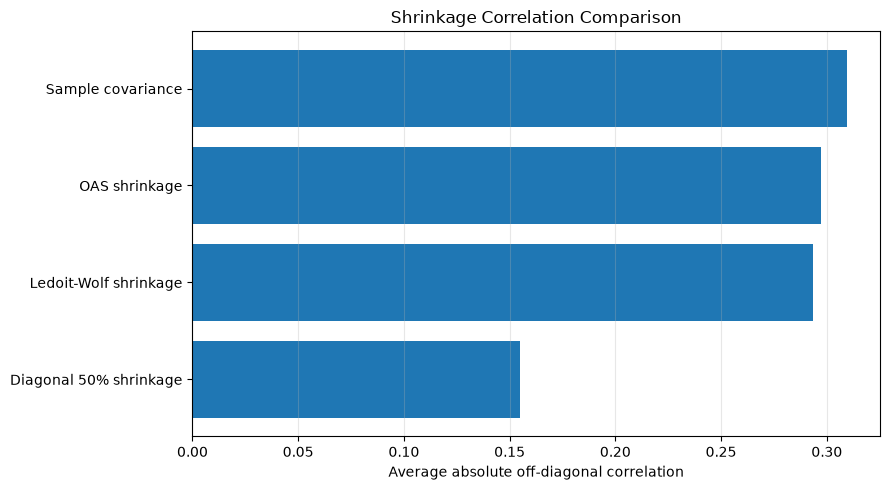

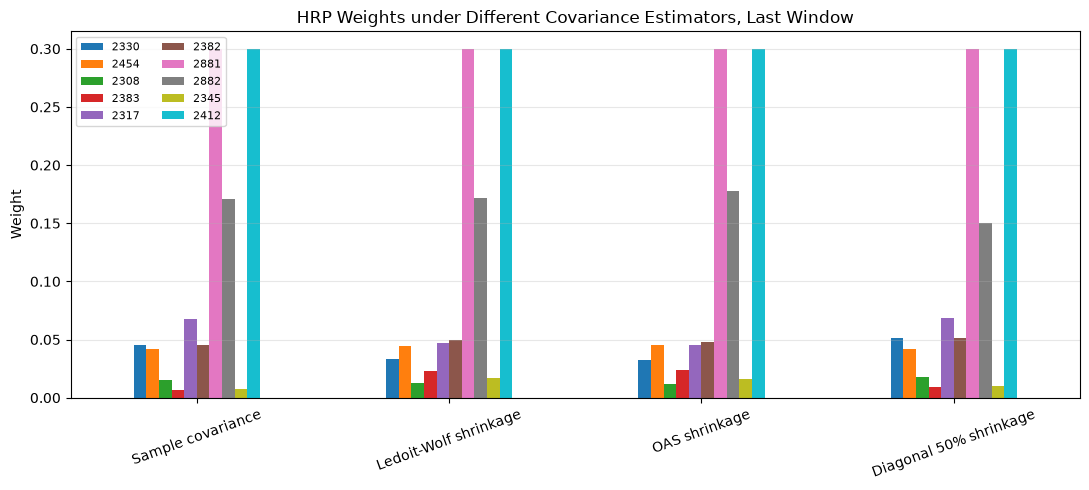

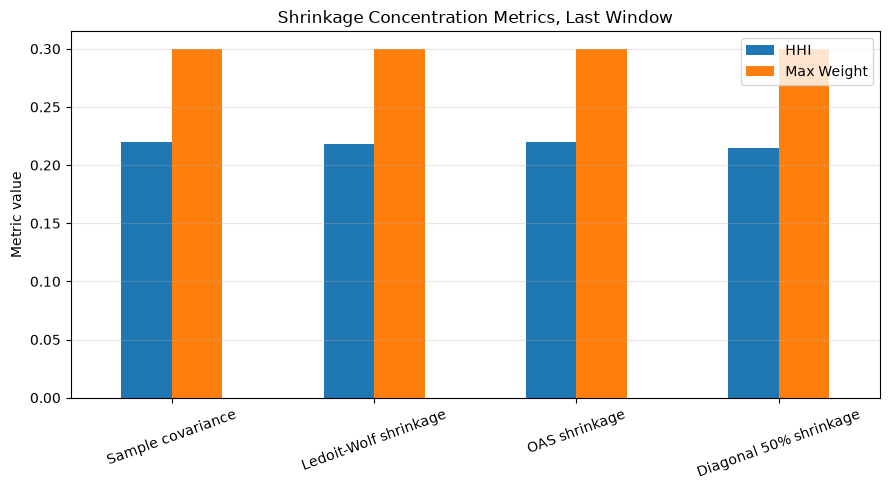

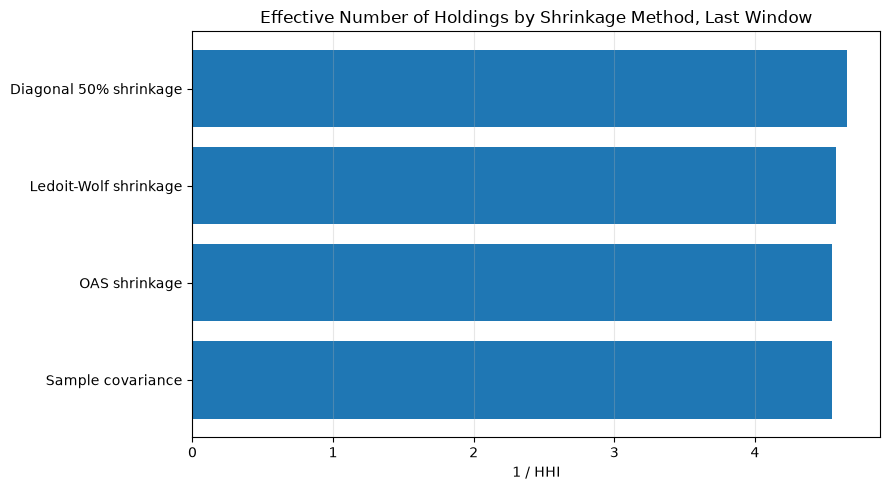

HRP shrinkage weights, last window


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
Sample covariance,0.0456,0.0415,0.0156,0.0065,0.0678,0.0453,0.3,0.1704,0.0073,0.3
Ledoit-Wolf shrinkage,0.0334,0.0444,0.0126,0.0233,0.0474,0.0495,0.3,0.1721,0.0172,0.3
OAS shrinkage,0.0321,0.0451,0.0120,0.0237,0.0456,0.0477,0.3,0.1773,0.0165,0.3
Diagonal 50% shrinkage,0.0514,0.0420,0.0178,0.0091,0.0686,0.0510,0.3,0.1501,0.0101,0.3


HRP shrinkage concentration metrics, last window


,HHI,Max Weight,Effective Number
Sample covariance,0.2198,0.3,4.5488
Ledoit-Wolf shrinkage,0.2184,0.3,4.5788
OAS shrinkage,0.2198,0.3,4.5488
Diagonal 50% shrinkage,0.2147,0.3,4.6568


Running HRP shrinkage rolling backtests...
  - HRP Sample covariance
  - HRP Ledoit-Wolf shrinkage
  - HRP OAS shrinkage
  - HRP Diagonal 50% shrinkage
HRP shrinkage rolling backtest performance, net of transaction costs


,Total Return,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Daily VaR 5%,Daily CVaR 95%,Avg Rebalance Turnover,Annualized Turnover,Total Transaction Cost,Annualized Transaction Cost,Avg Cost per Rebalance
Strategy,,,,,,,,,,,,
HRP Ledoit-Wolf shrinkage,9.268789,0.252712,0.154802,1.632488,-0.256732,-0.013721,-0.022178,0.084270,1.054389,0.073788,0.007386,0.000590
HRP OAS shrinkage,9.771270,0.258515,0.159456,1.621232,-0.266294,-0.014241,-0.022810,0.095485,1.194708,0.084197,0.008428,0.000674
HRP Sample covariance,9.433412,0.254641,0.160198,1.589543,-0.275895,-0.014410,-0.023137,0.110463,1.382114,0.098099,0.009819,0.000785
HRP Diagonal 50% shrinkage,8.786395,0.246895,0.155910,1.583571,-0.262568,-0.014033,-0.022490,0.098126,1.227745,0.086648,0.008673,0.000693


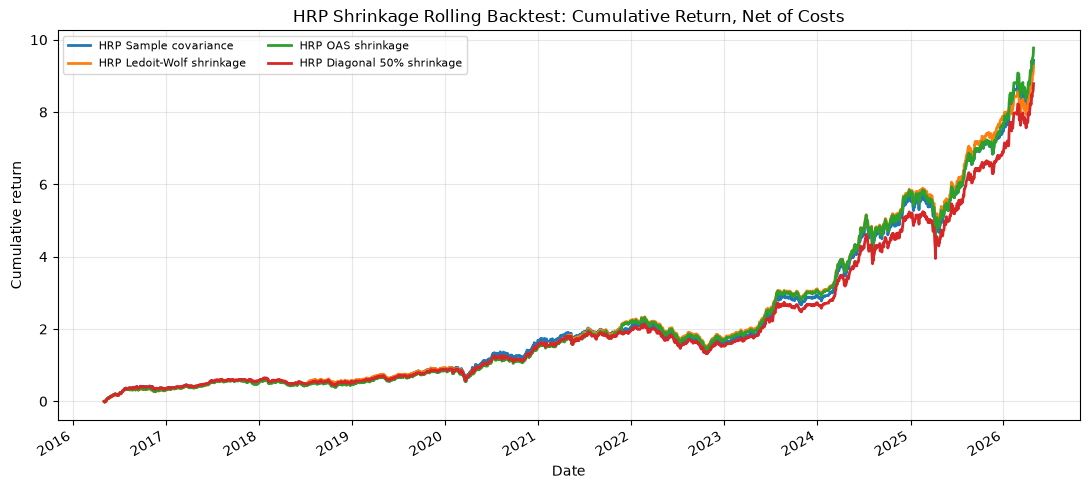

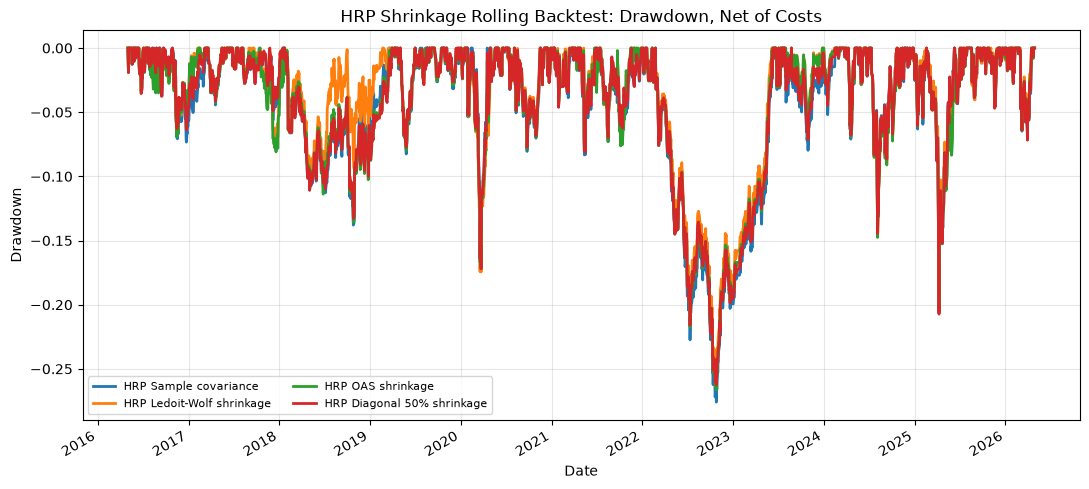

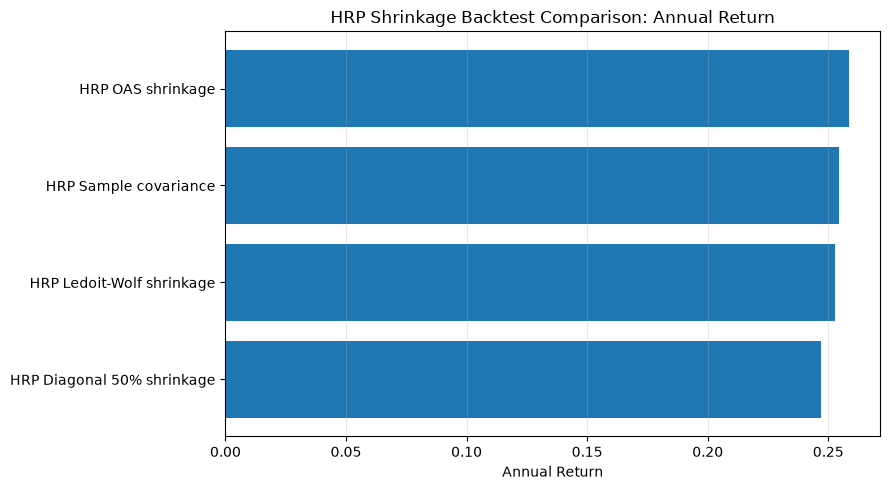

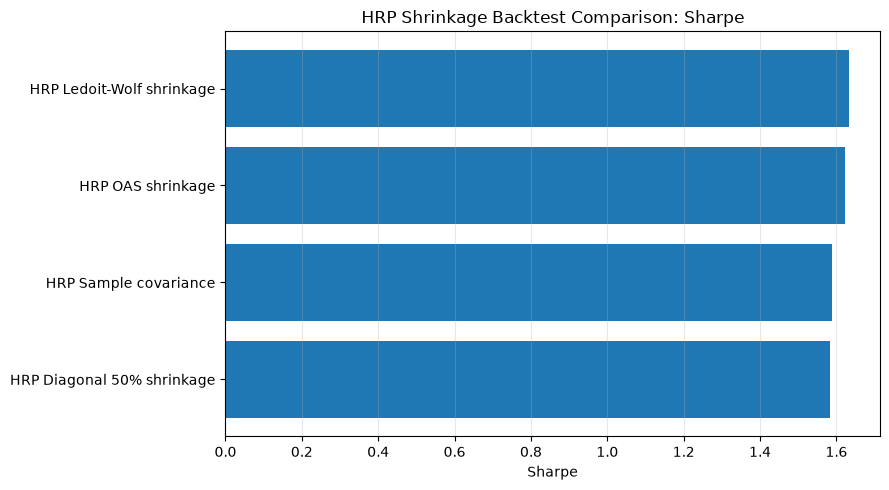

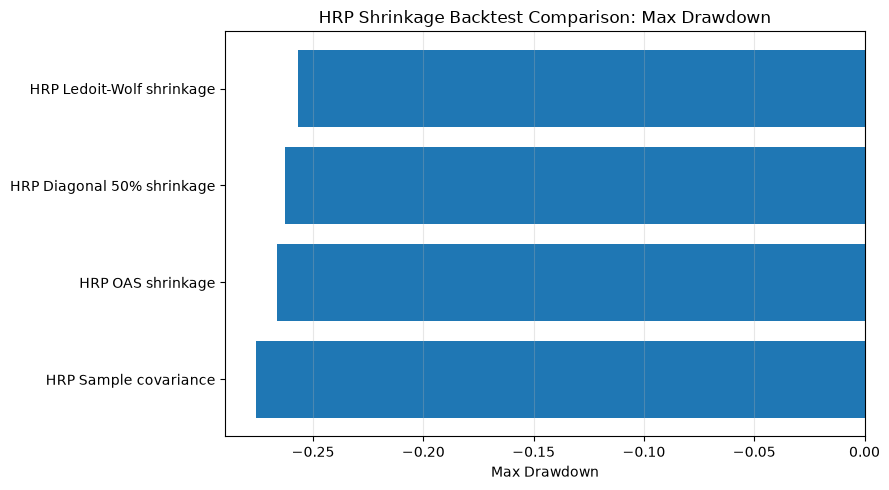

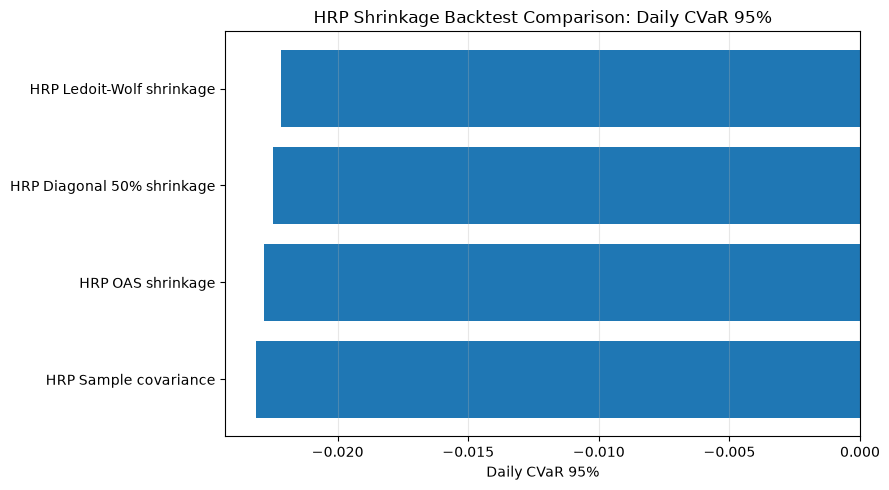

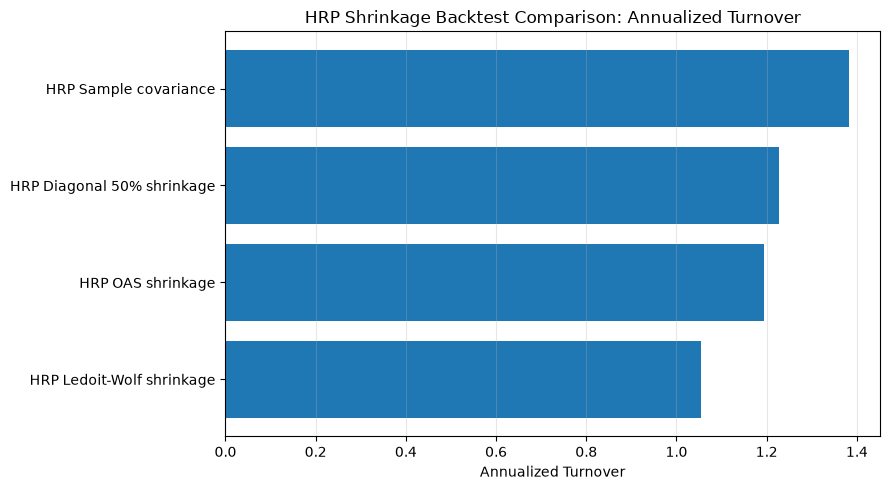

HRP shrinkage rolling average weights


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
HRP Sample covariance,0.0568,0.0486,0.0514,0.0652,0.0856,0.0950,0.1066,0.0845,0.1063,0.3000
HRP Ledoit-Wolf shrinkage,0.0562,0.0384,0.0535,0.0687,0.0861,0.0789,0.1185,0.0928,0.1073,0.2996
HRP OAS shrinkage,0.0525,0.0456,0.0501,0.0725,0.0878,0.0812,0.1114,0.0887,0.1102,0.2999
HRP Diagonal 50% shrinkage,0.0629,0.0461,0.0533,0.0559,0.0887,0.0917,0.1131,0.0916,0.0968,0.3000


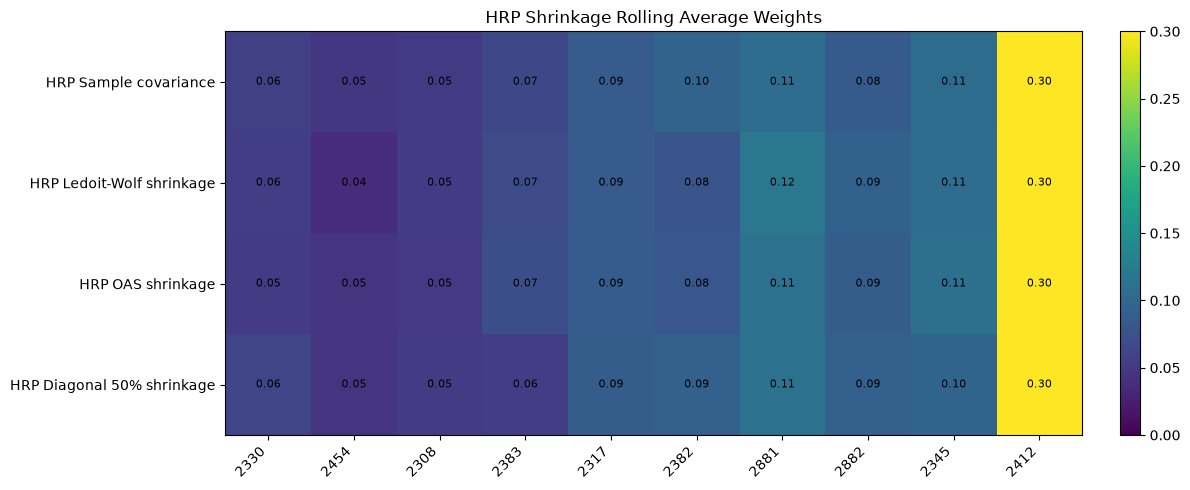

HRP shrinkage rolling backtest failure counts


,Failure count
HRP Sample covariance,0
HRP Ledoit-Wolf shrinkage,0
HRP OAS shrinkage,0
HRP Diagonal 50% shrinkage,0


In [12]:
# HRP shrinkage comparison 

from sklearn.covariance import LedoitWolf, OAS

def cov_to_corr(cov):

    cov = pd.DataFrame(cov).astype(float)
    diag = np.sqrt(np.maximum(np.diag(cov), 1e-12))
    corr = cov.values / np.outer(diag, diag)
    corr = np.nan_to_num(corr, nan=0.0, posinf=0.999, neginf=-0.999)
    corr = np.clip(corr, -0.999, 0.999)
    np.fill_diagonal(corr, 1.0)
    return pd.DataFrame(corr, index=cov.index, columns=cov.columns)


def estimate_shrinkage_covariance(train_returns, method, eps=1e-8):

    R = clean_training_returns(train_returns)
    cols = R.columns

    if R.shape[1] == 0:
        return pd.DataFrame()

    sample_cov = R.cov()

    try:
        if method == "Sample covariance":
            cov = sample_cov

        elif method == "Ledoit-Wolf shrinkage":
            cov = pd.DataFrame(
                LedoitWolf().fit(R.values).covariance_,
                index=cols,
                columns=cols,
            )

        elif method == "OAS shrinkage":
            cov = pd.DataFrame(
                OAS().fit(R.values).covariance_,
                index=cols,
                columns=cols,
            )

        elif method == "Diagonal 50% shrinkage":
            cov = pd.DataFrame(
                0.5 * sample_cov.values + 0.5 * np.diag(np.diag(sample_cov.values)),
                index=cols,
                columns=cols,
            )

        else:
            raise ValueError(f"Unknown shrinkage method: {method}")

    except Exception:
        cov = sample_cov

    return positive_semi_definite(pd.DataFrame(cov, index=cols, columns=cols), eps=eps)


def strategy_hrp_shrinkage(train_returns, method, cap=WEIGHT_CAP):
    """
    HRP strategy using a chosen covariance estimator.

    Pipeline:
    training returns
    -> shrinkage covariance
    -> covariance-to-correlation conversion
    -> HRP recursive bisection
    -> long-only capped weights
    """
    R = clean_training_returns(train_returns)
    cov = estimate_shrinkage_covariance(R, method=method)
    corr = cov_to_corr(cov)

    w, _, _ = hrp_diagnostic_from_cov_corr(cov, corr, cap=cap)
    return normalize_long_only_cap(w, cap=cap)

# Last-window diagnostic comparison

R_last = last_R.replace([np.inf, -np.inf], np.nan).fillna(0.0)
cols = R_last.columns

SHRINKAGE_METHODS = [
    "Sample covariance",
    "Ledoit-Wolf shrinkage",
    "OAS shrinkage",
    "Diagonal 50% shrinkage",
]

shrinkage_covs = {
    method: estimate_shrinkage_covariance(R_last, method=method)
    for method in SHRINKAGE_METHODS
}

shrinkage_weights = {}
shrinkage_corrs = {}

for name, cov in shrinkage_covs.items():
    corr = cov_to_corr(cov)
    w, _, _ = hrp_diagnostic_from_cov_corr(cov, corr)
    shrinkage_corrs[name] = corr
    shrinkage_weights[name] = normalize_long_only_cap(w, cap=WEIGHT_CAP)

avg_abs_corr = pd.Series({
    name: corr.where(~np.eye(len(corr), dtype=bool)).abs().stack().mean()
    for name, corr in shrinkage_corrs.items()
})

plot_bar(
    avg_abs_corr.sort_values(),
    "Shrinkage Correlation Comparison",
    "Average absolute off-diagonal correlation",
    "hrp_07_shrinkage_correlation_comparison.png",
)

shrinkage_weight_df = pd.DataFrame(shrinkage_weights).T

fig, ax = plt.subplots(figsize=(11, 5))
shrinkage_weight_df.plot(kind="bar", ax=ax)
ax.set_title("HRP Weights under Different Covariance Estimators, Last Window")
ax.set_ylabel("Weight")
ax.tick_params(axis="x", labelrotation=20)
ax.grid(True, axis="y", alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

concentration = pd.DataFrame({
    "HHI": (shrinkage_weight_df ** 2).sum(axis=1),
    "Max Weight": shrinkage_weight_df.max(axis=1),
})
concentration["Effective Number"] = 1.0 / concentration["HHI"]

fig, ax = plt.subplots(figsize=(9, 5))
concentration[["HHI", "Max Weight"]].plot(kind="bar", ax=ax)
ax.set_title("Shrinkage Concentration Metrics, Last Window")
ax.set_ylabel("Metric value")
ax.tick_params(axis="x", labelrotation=20)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plot_bar(
    concentration["Effective Number"].sort_values(),
    "Effective Number of Holdings by Shrinkage Method, Last Window",
    "1 / HHI",
    "hrp_10_shrinkage_effective_number.png",
)

display_table(
    shrinkage_weight_df,
    "HRP shrinkage weights, last window",
    "hrp_08_shrinkage_weights_comparison_table.csv",
    decimals=4,
)

display_table(
    concentration,
    "HRP shrinkage concentration metrics, last window",
    "hrp_09_10_shrinkage_concentration_table.csv",
    decimals=4,
)

# Rolling schedule builder for HRP shrinkage methods

def build_hrp_shrinkage_weight_schedule(
    returns_raw,
    method,
    train_window=TRAIN_WINDOW_DAILY,
    rebalance_freq=REBAL_FREQ_DAILY,
    cap=WEIGHT_CAP,
    first_rebalance_date=COMMON_BACKTEST_START,
    end_date=BACKTEST_END,
):

    returns_raw = returns_raw.replace([np.inf, -np.inf], np.nan).copy()
    all_columns = returns_raw.columns

    schedules = []
    failures = []

    first_rebalance_ts = pd.Timestamp(first_rebalance_date)
    end_ts = pd.Timestamp(end_date)

    start_t = max(
        train_window,
        returns_raw.index.searchsorted(first_rebalance_ts, side="left"),
    )

    for t in range(start_t, len(returns_raw), rebalance_freq):
        rebalance_date = returns_raw.index[t]

        if rebalance_date > end_ts:
            break

        train_returns_raw = returns_raw.iloc[t - train_window:t]
        train_returns = clean_training_returns(train_returns_raw)
        valid_cols = train_returns.columns.tolist()

        try:
            w_valid = strategy_hrp_shrinkage(
                train_returns,
                method=method,
                cap=cap,
            )

        except Exception as e:
            failures.append({
                "Method": method,
                "Date": rebalance_date,
                "Error": str(e),
            })
            print(f"[HRP {method}] failed at {rebalance_date.date()}: {e}. Use equal weight.")
            w_valid = equal_weight(valid_cols, cap=cap)

        w_all = pd.Series(w_valid, dtype=float).reindex(all_columns).fillna(0.0)
        w_all = normalize_long_only_cap(w_all, cap=cap)
        w_all.name = rebalance_date
        schedules.append(w_all)

    schedule = (
        pd.DataFrame(schedules).reindex(columns=all_columns).fillna(0.0)
        if schedules
        else pd.DataFrame(columns=all_columns)
    )

    return schedule, pd.DataFrame(failures)


# Rolling backtest for HRP shrinkage methods

hrp_shrinkage_weight_schedules = {}
hrp_shrinkage_returns = {}
hrp_shrinkage_transaction_logs = {}
hrp_shrinkage_failures = {}

returns_for_backtest = asset_daily_returns_safe.loc[:BACKTEST_END].copy()

print("Running HRP shrinkage rolling backtests...")

for method in SHRINKAGE_METHODS:
    strategy_name = f"HRP {method}"
    print("  -", strategy_name)

    ws, failures = build_hrp_shrinkage_weight_schedule(
        returns_raw=returns_for_backtest,
        method=method,
        train_window=TRAIN_WINDOW_DAILY,
        rebalance_freq=REBAL_FREQ_DAILY,
        cap=WEIGHT_CAP,
        first_rebalance_date=COMMON_BACKTEST_START,
        end_date=BACKTEST_END,
    )

    ret, cost_log = portfolio_returns_from_schedule(
        returns_for_backtest,
        ws,
        buy_fee_rate=BUY_FEE_RATE,
        sell_fee_rate=SELL_FEE_RATE,
        return_cost_log=True,
    )

    ret = ret.loc[COMMON_FIRST_TRADING_DATE:BACKTEST_END]

    hrp_shrinkage_weight_schedules[strategy_name] = ws
    hrp_shrinkage_returns[strategy_name] = ret
    hrp_shrinkage_transaction_logs[strategy_name] = cost_log
    hrp_shrinkage_failures[strategy_name] = failures

hrp_shrinkage_returns_df = pd.DataFrame(hrp_shrinkage_returns).dropna(how="all")

# Performance summary for HRP shrinkage methods

def _hrp_shrinkage_max_drawdown(ret):
    ret = pd.Series(ret).dropna()
    wealth = (1.0 + ret).cumprod()
    drawdown = wealth / wealth.cummax() - 1.0
    return float(drawdown.min())


def _hrp_shrinkage_cvar_left_tail(ret, alpha=0.95):
    ret = pd.Series(ret).dropna()
    if len(ret) == 0:
        return np.nan
    var_level = np.percentile(ret, (1.0 - alpha) * 100)
    return float(ret[ret <= var_level].mean())


def hrp_shrinkage_performance_summary(
    returns_df,
    transaction_logs=None,
    periods_per_year=252
):
    rows = []

    for col in returns_df.columns:
        r = returns_df[col].dropna()

        if len(r) == 0:
            continue

        total_return = float((1.0 + r).prod() - 1.0)
        ann_return = float((1.0 + total_return) ** (periods_per_year / len(r)) - 1.0)
        ann_vol = float(r.std() * np.sqrt(periods_per_year))
        sharpe = float(ann_return / ann_vol) if ann_vol > 0 else np.nan

        avg_reb_turnover = np.nan
        ann_turnover = np.nan
        total_tc = np.nan
        ann_tc = np.nan
        avg_tc = np.nan

        if transaction_logs is not None and col in transaction_logs:
            avg_reb_turnover, ann_turnover = realized_turnover_stats(transaction_logs[col], r.index)
            total_tc, ann_tc, avg_tc = transaction_cost_stats(transaction_logs[col], r.index)

        rows.append({
            "Strategy": col,
            "Total Return": total_return,
            "Annual Return": ann_return,
            "Annual Volatility": ann_vol,
            "Sharpe": sharpe,
            "Max Drawdown": _hrp_shrinkage_max_drawdown(r),
            "Daily VaR 5%": float(np.percentile(r, 5)),
            "Daily CVaR 95%": _hrp_shrinkage_cvar_left_tail(r, alpha=0.95),
            "Avg Rebalance Turnover": avg_reb_turnover,
            "Annualized Turnover": ann_turnover,
            "Total Transaction Cost": total_tc,
            "Annualized Transaction Cost": ann_tc,
            "Avg Cost per Rebalance": avg_tc,
        })

    return pd.DataFrame(rows).set_index("Strategy").sort_values("Sharpe", ascending=False)


hrp_shrinkage_summary = hrp_shrinkage_performance_summary(
    hrp_shrinkage_returns_df,
    transaction_logs=hrp_shrinkage_transaction_logs,
)

display_table(
    hrp_shrinkage_summary,
    "HRP shrinkage rolling backtest performance, net of transaction costs",
    "hrp_shrinkage_backtest_performance_table.csv",
    decimals=6,
)



# Rolling backtest plots

hrp_shrinkage_cumret = (1.0 + hrp_shrinkage_returns_df).cumprod() - 1.0

fig, ax = plt.subplots(figsize=(11, 5))
hrp_shrinkage_cumret.plot(ax=ax, linewidth=2)
ax.set_title("HRP Shrinkage Rolling Backtest: Cumulative Return, Net of Costs")
ax.set_ylabel("Cumulative return")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

hrp_shrinkage_drawdown = (
    (1.0 + hrp_shrinkage_returns_df).cumprod()
    / (1.0 + hrp_shrinkage_returns_df).cumprod().cummax()
    - 1.0
)

fig, ax = plt.subplots(figsize=(11, 5))
hrp_shrinkage_drawdown.plot(ax=ax, linewidth=2)
ax.set_title("HRP Shrinkage Rolling Backtest: Drawdown, Net of Costs")
ax.set_ylabel("Drawdown")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

for metric in ["Annual Return", "Sharpe", "Max Drawdown", "Daily CVaR 95%", "Annualized Turnover"]:
    s = hrp_shrinkage_summary[metric].copy()
    s = s.sort_values(ascending=True if metric in ["Max Drawdown", "Daily CVaR 95%"] else False)

    plot_bar(
        s,
        f"HRP Shrinkage Backtest Comparison: {metric}",
        metric,
        f"hrp_shrinkage_backtest_{metric.lower().replace(' ', '_').replace('%', 'pct')}.png",
        horizontal=True,
    )


# Rolling average weights

hrp_shrinkage_average_weights = pd.DataFrame({
    name: ws.mean(axis=0)
    for name, ws in hrp_shrinkage_weight_schedules.items()
}).T

display_table(
    hrp_shrinkage_average_weights,
    "HRP shrinkage rolling average weights",
    "hrp_shrinkage_rolling_average_weights_table.csv",
    decimals=4,
)

plot_heatmap(
    hrp_shrinkage_average_weights,
    "HRP Shrinkage Rolling Average Weights",
    "hrp_shrinkage_rolling_average_weights_heatmap.png",
    vmin=0,
    vmax=WEIGHT_CAP,
    annotate=True,
    fmt=".2f",
    figsize=(12, 5),
)

hrp_shrinkage_failure_summary = pd.Series({
    name: len(failures)
    for name, failures in hrp_shrinkage_failures.items()
}).to_frame("Failure count")

display_table(
    hrp_shrinkage_failure_summary,
    "HRP shrinkage rolling backtest failure counts",
    "hrp_shrinkage_failure_counts_table.csv",
    decimals=0,
)

## 7. Covariance-based minimum variance benchmarks

比較三種 covariance-based minimum variance 策略。三種策略最後都會使用相同的 `solve_min_variance()`，差別只在於 covariance matrix 的估計方式。

共同的 minimum variance problem 為：

$$
\min_w
\quad
w^\top \Sigma w
$$

subject to：

$$
\sum_{i=1}^{N}w_i = 1
$$

$$
0 \leq w_i \leq \text{WEIGHT\_CAP}
$$

因此，三種策略的比較重點在於 $\Sigma$ 如何估計。

#### Empirical MinVar

Empirical MinVar 直接使用歷史報酬的樣本 covariance matrix：

$$
\hat{\Sigma}_{\text{emp}}
=
\frac{1}{T-1}
(R-\bar{R})^\top(R-\bar{R})
$$

這是最直接的 benchmark，但在資產高度相關或樣本數有限時，樣本 covariance 容易受到估計誤差影響。

#### PCA MinVar

PCA MinVar 先對報酬矩陣中心化，再用 PCA 抽取主要共同成分。PCA covariance 可以寫成：

$$
\Sigma_{\text{PCA}}
=
V_k \Lambda_k V_k^\top
+
D_{\text{res}}
$$

其中：

| 符號 | 意義 |
|---|---|
| $V_k$ | 前 $k$ 個主成分方向 |
| $\Lambda_k$ | 前 $k$ 個主成分的變異數 |
| $D_res$ | PCA 無法解釋的殘差變異數對角矩陣 |

PCA MinVar 的優點是降低 covariance matrix 的 noise；缺點是 PCA 主成分未必有清楚的經濟意義。

#### Factor MinVar

Factor MinVar 使用外部因子建立 covariance matrix。模型為：

$$
X
=
\mathbf{1}\alpha^\top
+
F B^\top
+
E
$$

因此 factor-implied covariance 為：

$$
\Sigma_{\text{FM}}
=
B\Sigma_fB^\top
+
D
$$

其中 $B \Sigma_f B^T$ 是外部因子解釋的系統性風險，$D$ 是殘差變異數。

In [13]:
def strategy_empirical_minvar(train_returns, cap=WEIGHT_CAP):
    R = clean_training_returns(train_returns)
    return solve_min_variance(R.cov(), cap=cap)

# PCA covariance
def pca_covariance(train_returns, n_components=PCA_COMPONENTS, eps=1e-8):
    X = clean_training_returns(train_returns)
    cols = X.columns
    # PCA 主成分數量不可超過資產數
    k = min(n_components, len(cols), max(1, len(X) - 1))
    X_centered = X - X.mean(axis=0)
    pca = PCA(n_components=k)
    scores = pca.fit_transform(X_centered.values)
    factor_cov = pca.components_.T @ np.diag(pca.explained_variance_) @ pca.components_
    X_hat = pca.inverse_transform(scores)
    residual = X_centered.values - X_hat
    resid_var = np.maximum(residual.var(axis=0, ddof=1), eps)
    sigma = factor_cov + np.diag(resid_var)
    return positive_semi_definite(pd.DataFrame(sigma, index=cols, columns=cols), eps=eps)


def strategy_pca_minvar_monthly(train_monthly_returns, cap=WEIGHT_CAP):
    sigma = pca_covariance(train_monthly_returns, n_components=PCA_COMPONENTS)
    return solve_min_variance(sigma, cap=cap)

# factor-implied covariance
def factor_implied_covariance(asset_returns, factor_returns, ridge_alpha=1e-6, eps=1e-8):
    X = clean_training_returns(asset_returns, min_obs=max(12, int(len(asset_returns) * 0.50)))
    F = clean_factor_returns(factor_returns, X.index)
    X, F = X.align(F, join="inner", axis=0)
    cols = X.columns
    factors = F.columns

    if len(X) < len(factors) + 3:
        return positive_semi_definite(X.cov(), eps=eps)

    X_np = X.values
    F_np = F.values
    Z = np.column_stack([np.ones(len(F_np)), F_np])
    penalty = np.eye(Z.shape[1]) * ridge_alpha
    penalty[0, 0] = 0.0
    coef = np.linalg.solve(Z.T @ Z + penalty, Z.T @ X_np)
    B = coef[1:, :].T
    fitted = Z @ coef
    eps_mat = X_np - fitted
    Sigma_f = np.cov(F_np, rowvar=False, ddof=1)
    if Sigma_f.ndim == 0:
        Sigma_f = np.array([[float(Sigma_f)]])
    resid_var = np.maximum(eps_mat.var(axis=0, ddof=1), eps)
    sigma = B @ Sigma_f @ B.T + np.diag(resid_var)
    return positive_semi_definite(pd.DataFrame(sigma, index=cols, columns=cols), eps=eps)


def strategy_factor_minvar_monthly(train_monthly_returns, train_factor_returns, cap=WEIGHT_CAP):
    sigma = factor_implied_covariance(train_monthly_returns, train_factor_returns)
    return solve_min_variance(sigma, cap=cap)


last_monthly = asset_monthly_returns.loc[:BACKTEST_END].dropna(how="all").tail(TRAIN_WINDOW_MONTHLY).fillna(0.0)
last_factor_monthly = factor_monthly_returns.reindex(last_monthly.index).fillna(0.0)
comparison_weights = pd.DataFrame({
    "Empirical MinVar": solve_min_variance(last_monthly.cov()),
    "PCA MinVar": solve_min_variance(pca_covariance(last_monthly)),
    "Factor MinVar": solve_min_variance(factor_implied_covariance(last_monthly, last_factor_monthly)),
}).T
display_table(comparison_weights, "Single-window MinVar benchmark weights", "minvar_single_window_weights_table.csv", decimals=4)

Single-window MinVar benchmark weights


,2330,2454,2308,2383,2317,2382,2881,2882,2345,2412
Empirical MinVar,0.1882,0.0138,0.0297,0.0401,0.0108,0.1005,0.1839,0.0000,0.1332,0.3
PCA MinVar,0.0887,0.0428,0.0241,0.0656,0.0254,0.0821,0.1657,0.1257,0.0798,0.3
Factor MinVar,0.0672,0.0483,0.0459,0.0537,0.0663,0.0619,0.1748,0.1187,0.0631,0.3


## 8. Common Backtest Framework and Ensembling

### 8.1. Schedule builders

前面的策略函數只會在單一訓練視窗中產生一組權重。這個 chunk 的任務是將策略函數轉成完整的 rolling weight schedule。

對日頻策略，例如 CVaR、Empirical MinVar、HRP Pearson、HRP DCCA 與 HRP 1/n，流程為：

1. 使用過去 252 個交易日作為 training window。
2. 每隔 21 個交易日重新估計一次權重。
3. 將每次再平衡的權重整理成 `weight_schedule`。
4. 交給共同的 drift-aware backtest function 計算每日淨報酬。

對月頻策略，例如 Factor MinVar 與 PCA MinVar，流程為：

1. 使用過去 36 個月月報酬估計 covariance matrix。
2. 在月資料估計完成後，將權重套用到下一個可交易日。
3. 在日頻回測中持有該權重，直到下一次月頻估計更新。


In [14]:
def expand_weights_to_all_assets(w, all_columns, cap=WEIGHT_CAP):
    w = pd.Series(w, dtype=float).reindex(all_columns).fillna(0.0)
    return normalize_long_only_cap(w, cap=cap)


def build_daily_weight_schedule(
    prices,
    returns_raw,
    strategy_name,
    strategy_func,
    train_window=TRAIN_WINDOW_DAILY,
    rebalance_freq=REBAL_FREQ_DAILY,
    cap=WEIGHT_CAP,
    first_rebalance_date=None,
):
    schedules, failures = [], []

    start_t = train_window
    if first_rebalance_date is not None:
        start_t = max(start_t, returns_raw.index.searchsorted(pd.Timestamp(first_rebalance_date), side="left"))

    for t in range(start_t, len(returns_raw), rebalance_freq):
        rebalance_date = returns_raw.index[t]
        train_returns_raw = returns_raw.iloc[t-train_window:t]
        train_returns = clean_training_returns(train_returns_raw)
        valid_cols = train_returns.columns.tolist()
        train_prices = prices.loc[train_returns_raw.index, valid_cols].copy().ffill()
        try:
            w = strategy_func(train_prices, train_returns, cap=cap) if strategy_name == "HRP DCCA" else strategy_func(train_returns, cap=cap)
        except Exception as e:
            failures.append({"Strategy": strategy_name, "Date": rebalance_date, "Error": str(e)})
            print(f"[{strategy_name}] failed at {rebalance_date.date()}: {e}. Use equal weight.")
            w = equal_weight(valid_cols, cap=cap)
        w = expand_weights_to_all_assets(w, returns_raw.columns, cap=cap)
        w.name = rebalance_date
        schedules.append(w)
    schedule = pd.DataFrame(schedules).reindex(columns=returns_raw.columns).fillna(0.0) if schedules else pd.DataFrame(columns=returns_raw.columns)
    return schedule, pd.DataFrame(failures)


def build_monthly_to_daily_weight_schedule(
    daily_returns_index,
    monthly_asset_returns_raw,
    monthly_factor_returns_raw,
    strategy_name,
    strategy_func,
    train_window_monthly=TRAIN_WINDOW_MONTHLY,
    cap=WEIGHT_CAP,
    first_apply_date=None,
):
    schedules, failures = [], []
    all_columns = monthly_asset_returns_raw.columns
    first_apply_ts = pd.Timestamp(first_apply_date) if first_apply_date is not None else None

    for i in range(train_window_monthly - 1, len(monthly_asset_returns_raw)):
        estimation_month_end = monthly_asset_returns_raw.index[i]
        next_daily_pos = daily_returns_index.searchsorted(estimation_month_end, side="right")
        if next_daily_pos >= len(daily_returns_index):
            continue
        apply_date = daily_returns_index[next_daily_pos]
        if first_apply_ts is not None and apply_date < first_apply_ts:
            continue

        train_asset_raw = monthly_asset_returns_raw.iloc[i-train_window_monthly+1:i+1]
        train_asset = clean_training_returns(train_asset_raw, min_obs=max(12, int(train_window_monthly*0.50)))
        try:
            if strategy_name == "Factor MinVar":
                train_factor = clean_factor_returns(monthly_factor_returns_raw, train_asset.index)
                w = strategy_func(train_asset, train_factor, cap=cap)
            else:
                w = strategy_func(train_asset, cap=cap)
        except Exception as e:
            failures.append({"Strategy": strategy_name, "MonthEnd": estimation_month_end, "ApplyDate": apply_date, "Error": str(e)})
            print(f"[{strategy_name}] failed at {estimation_month_end.date()}: {e}. Use equal weight.")
            w = equal_weight(train_asset.columns, cap=cap)
        w = expand_weights_to_all_assets(w, all_columns, cap=cap)
        w.name = apply_date
        schedules.append(w)
    schedule = pd.DataFrame(schedules).reindex(columns=all_columns).fillna(0.0) if schedules else pd.DataFrame(columns=all_columns)
    return schedule, pd.DataFrame(failures)

### 8.2. Run all strategies

正式執行所有策略，並將權重排程、每日報酬、交易成本統一存入 dictionary。

日頻策略包括：

| 策略 | 訓練資料 | 再平衡頻率 |
|---|---|---|
| Equal Weight | 當期可用股票欄位 | 21 個交易日 |
| CVaR | 過去 252 日股票報酬 | 21 個交易日 |
| Empirical MinVar | 過去 252 日股票報酬 | 21 個交易日 |
| HRP Pearson | 過去 252 日股票報酬 | 21 個交易日 |
| HRP DCCA | 過去 252 日價格與報酬 | 21 個交易日 |
| HRP 1/n | 過去 252 日股票報酬 | 21 個交易日 |

月頻策略包括：

| 策略 | 訓練資料 | 套用方式 |
|---|---|---|
| Factor MinVar | 過去 36 個月股票與因子月報酬 | 月底估計後套用到下一個交易日 |
| PCA MinVar | 過去 36 個月股票月報酬 | 月底估計後套用到下一個交易日 |

每個策略都會經過相同的交易成本與 passive drift 回測：

$$
1+r^{\text{net}}_{p,t}
=
(1-\kappa_t)(1+w_t^\top r_t)
$$

最後得到的 `returns_df` 是各策略的日頻淨報酬表，後續所有績效比較都以此為基礎。


In [15]:
daily_strategy_funcs = {
    "Equal Weight": lambda train_returns, cap=WEIGHT_CAP: equal_weight(train_returns.columns, cap=cap),
    "CVaR": strategy_cvar,
    "Empirical MinVar": strategy_empirical_minvar,
    "HRP Pearson": strategy_hrp_pearson,
    "HRP DCCA": strategy_hrp_dcca,
    "HRP 1/n": strategy_hrp_one_over_n,
}

monthly_strategy_funcs = {
    "Factor MinVar": strategy_factor_minvar_monthly,
    "PCA MinVar": strategy_pca_minvar_monthly,
}

all_weight_schedules = {}
all_portfolio_returns = {}
all_transaction_logs = {}
all_failure_logs = {}

print("Running daily-frequency strategies...")
for name, func in daily_strategy_funcs.items():
    print("  -", name)
    ws, failures = build_daily_weight_schedule(
        prices=asset_prices_bt,
        returns_raw=asset_daily_returns,
        strategy_name=name,
        strategy_func=func,
        train_window=TRAIN_WINDOW_DAILY,
        rebalance_freq=REBAL_FREQ_DAILY,
        cap=WEIGHT_CAP,
        first_rebalance_date=COMMON_BACKTEST_START,
    )
    ret, cost_log = portfolio_returns_from_schedule(asset_daily_returns_safe, ws, return_cost_log=True)
    all_weight_schedules[name] = ws
    all_portfolio_returns[name] = ret
    all_transaction_logs[name] = cost_log
    all_failure_logs[name] = failures

print("Running monthly-estimated, daily-held strategies...")
for name, func in monthly_strategy_funcs.items():
    print("  -", name)
    ws, failures = build_monthly_to_daily_weight_schedule(
        daily_returns_index=asset_daily_returns_safe.index,
        monthly_asset_returns_raw=asset_monthly_returns.loc[:, asset_daily_returns_safe.columns],
        monthly_factor_returns_raw=factor_monthly_returns.loc[:, FACTOR_COLUMNS],
        strategy_name=name,
        strategy_func=func,
        train_window_monthly=TRAIN_WINDOW_MONTHLY,
        cap=WEIGHT_CAP,
        first_apply_date=COMMON_BACKTEST_START,
    )
    ret, cost_log = portfolio_returns_from_schedule(asset_daily_returns_safe, ws, return_cost_log=True)
    all_weight_schedules[name] = ws
    all_portfolio_returns[name] = ret
    all_transaction_logs[name] = cost_log
    all_failure_logs[name] = failures

returns_df = pd.concat(all_portfolio_returns, axis=1).dropna(how="all").dropna(how="any")
returns_df = returns_df.loc[pd.Timestamp(COMMON_BACKTEST_START):pd.Timestamp(BACKTEST_END)]
strategy_order = ["Equal Weight", "CVaR", "Empirical MinVar", "HRP Pearson", "HRP DCCA", "HRP 1/n", "Factor MinVar", "PCA MinVar"]
returns_df = returns_df[[c for c in strategy_order if c in returns_df.columns]]

print("Backtest result shape:", returns_df.shape)
print("Common backtest period:", returns_df.index.min().date(), "→", returns_df.index.max().date())
print("Requested common start:", COMMON_BACKTEST_START, "| first trading date:", COMMON_FIRST_TRADING_DATE.date())
print("Factor columns used by Factor MinVar:", FACTOR_COLUMNS)
print(f"Buy fee rate : {BUY_FEE_RATE:.4%}")
print(f"Sell fee rate: {SELL_FEE_RATE:.4%}")
for name, failures in all_failure_logs.items():
    print(f"{name:18s} failures: {len(failures)}")

if "HRP DCCA" in all_weight_schedules:
    ew_schedule = all_weight_schedules["Equal Weight"].reindex(all_weight_schedules["HRP DCCA"].index).ffill()
    dcca_schedule = all_weight_schedules["HRP DCCA"]
    common_idx = dcca_schedule.index.intersection(ew_schedule.index)
    dcca_l1_from_ew = (dcca_schedule.loc[common_idx] - ew_schedule.loc[common_idx]).abs().sum(axis=1)
    print("HRP DCCA average L1 distance from Equal Weight:", float(dcca_l1_from_ew.mean()))
    print("HRP DCCA max L1 distance from Equal Weight:", float(dcca_l1_from_ew.max()))

display(returns_df.head())
display(returns_df.tail())

Running daily-frequency strategies...
  - Equal Weight
  - CVaR
  - Empirical MinVar
  - HRP Pearson
  - HRP DCCA
  - HRP 1/n
Running monthly-estimated, daily-held strategies...
  - Factor MinVar
  - PCA MinVar
Backtest result shape: (2605, 8)
Common backtest period: 2016-05-02 → 2026-04-29
Requested common start: 2016-05-01 | first trading date: 2016-05-02
Factor columns used by Factor MinVar: ['TWII', 'SOX', 'USDTWD']
Buy fee rate : 0.3000%
Sell fee rate: 0.4425%
Equal Weight       failures: 0
CVaR               failures: 0
Empirical MinVar   failures: 0
HRP Pearson        failures: 0
HRP DCCA           failures: 0
HRP 1/n            failures: 0
Factor MinVar      failures: 0
PCA MinVar         failures: 0
HRP DCCA average L1 distance from Equal Weight: 0.7538103843678192
HRP DCCA max L1 distance from Equal Weight: 1.0235748465443337


,Equal Weight,CVaR,Empirical MinVar,HRP Pearson,HRP DCCA,HRP 1/n,Factor MinVar,PCA MinVar
2016-05-02,-0.003000,-0.003000,-0.003000,-0.003000,-0.003000,-0.003000,-0.003000,-0.003000
2016-05-03,-0.016107,-0.005879,-0.009523,-0.011016,-0.012407,-0.015094,-0.004170,-0.007942
2016-05-04,-0.012489,-0.009644,-0.010014,-0.007988,-0.008161,-0.009239,-0.004933,-0.004971
2016-05-05,0.002102,-0.001727,-0.000274,0.005887,0.006411,0.003017,-0.001618,-0.000737
2016-05-06,-0.006917,-0.001014,-0.002816,0.011248,0.010612,-0.004139,-0.003205,-0.003815


,Equal Weight,CVaR,Empirical MinVar,HRP Pearson,HRP DCCA,HRP 1/n,Factor MinVar,PCA MinVar
2026-04-23,-0.013475,-0.009575,-0.010043,-0.006682,-0.008213,-0.012451,-0.011562,-0.011668
2026-04-24,0.034446,0.007068,0.026972,0.009132,0.012539,0.028404,0.020509,0.023851
2026-04-27,0.013557,0.012160,0.016546,0.006967,0.007267,0.009969,0.010210,0.013385
2026-04-28,0.007067,-0.005796,-0.001765,0.007159,0.006622,0.006498,0.007364,0.003572
2026-04-29,0.003954,0.013638,0.004306,0.015250,0.017141,0.007623,0.006551,0.004797


### 8.3. Performance summary

將各策略的日頻淨報酬轉換成績效統計表。主要指標包括 Total Return、Annual Return、Annual Volatility、Sharpe、Max Drawdown、Daily VaR、Daily CVaR、Turnover 與 Transaction Cost。

#### (1) Total return

$$
R_{\text{total}}
=
\prod_{t=1}^{T}(1+r_t)-1
$$

#### (2) Annualized return

$$
R_{\text{ann}}
=
(1+R_{\text{total}})^{\frac{252}{T}}-1
$$

#### (3) Annualized volatility

$$
\sigma_{\text{ann}}
=
\sigma_{\text{daily}}\sqrt{252}
$$

#### (4) Sharpe ratio

使用簡化 Sharpe ratio：

$$
\text{Sharpe}
=
\frac{R_{\text{ann}}}{\sigma_{\text{ann}}}
$$

#### Maximum drawdown

定義累積財富：

$$
W_t
=
\prod_{\tau=1}^{t}(1+r_\tau)
$$

drawdown 為：

$$
DD_t
=
\frac{W_t}{\max_{\tau \leq t} W_\tau}-1
$$

最大回撤為：

$$
\text{Max Drawdown}
=
\min_t DD_t
$$

#### Daily CVaR 95%

Daily CVaR 95% 這裡以報酬左尾衡量，因此數值通常為負數：

$$
\operatorname{CVaR}_{0.95}
=
E[r_t \mid r_t \leq q_{0.05}]
$$

若 CVaR 越接近 0，代表極端虧損時的平均損失較小。


,Total Return,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Daily VaR 5%,Daily CVaR 95%,Avg Rebalance Turnover,Annualized Turnover,Total Transaction Cost,Annualized Transaction Cost,Avg Cost per Rebalance
Strategy,,,,,,,,,,,,
HRP 1/n,15.6224,0.3125,0.1891,1.6527,-0.2712,-0.0175,-0.0275,0.0879,1.1004,0.0772,0.0077,0.0006
Equal Weight,15.7689,0.3136,0.1905,1.6462,-0.2944,-0.0171,-0.0276,0.0341,0.4270,0.0272,0.0027,0.0002
HRP Pearson,9.4334,0.2546,0.1602,1.5895,-0.2759,-0.0144,-0.0231,0.1105,1.3821,0.0981,0.0098,0.0008
Empirical MinVar,7.5996,0.2314,0.1477,1.5670,-0.2423,-0.0130,-0.0212,0.0730,0.9139,0.0634,0.0063,0.0005
CVaR,6.5218,0.2155,0.1400,1.5402,-0.2017,-0.0125,-0.0199,0.1077,1.3477,0.0955,0.0096,0.0008
HRP DCCA,9.2514,0.2525,0.1646,1.5337,-0.2379,-0.0148,-0.0233,0.1449,1.8128,0.1300,0.0130,0.0010
Factor MinVar,6.6379,0.2174,0.1443,1.5060,-0.2296,-0.0131,-0.0210,0.0485,0.5828,0.0388,0.0039,0.0003
PCA MinVar,6.4905,0.2151,0.1431,1.5024,-0.2352,-0.0127,-0.0207,0.0551,0.6615,0.0446,0.0045,0.0004


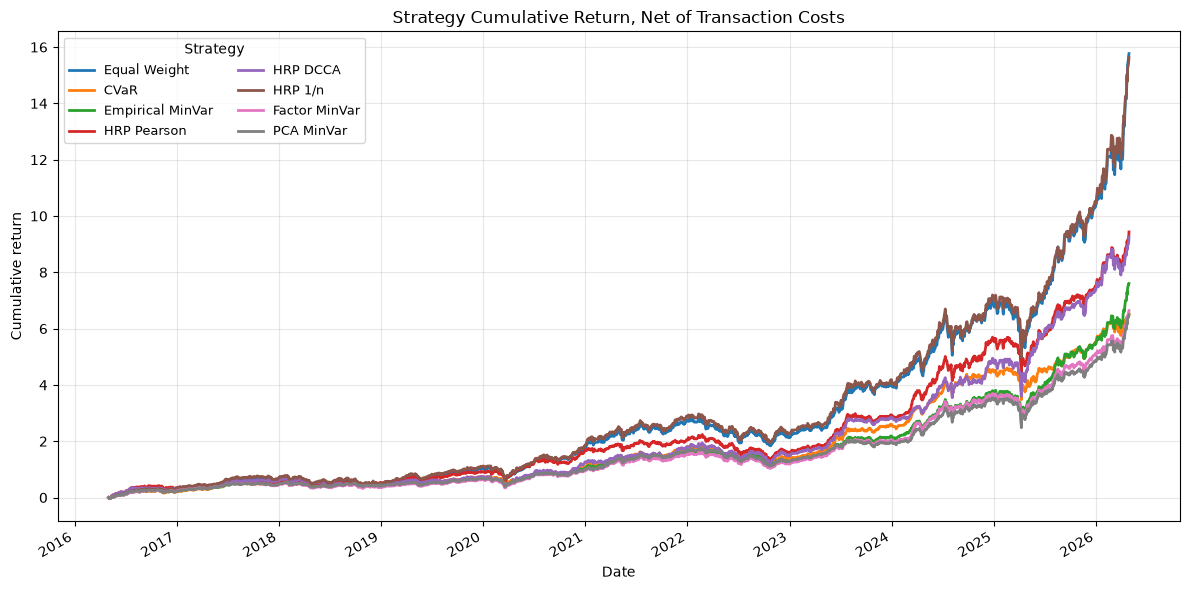

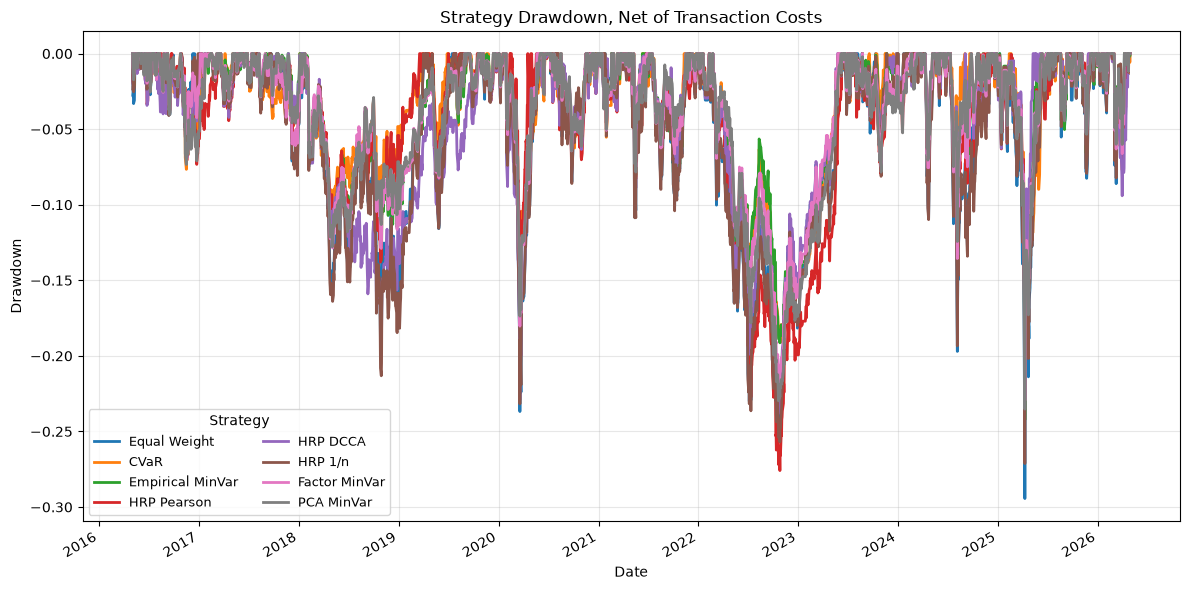

In [16]:
def max_drawdown(ret):
    wealth = (1.0 + ret).cumprod()
    return float((wealth / wealth.cummax() - 1.0).min())


def cvar_left_tail(ret, alpha=0.95):
    ret = ret.dropna()
    var_level = np.percentile(ret, (1 - alpha) * 100)
    return float(ret[ret <= var_level].mean())


def performance_summary(returns_df, weight_schedules=None, transaction_logs=None, periods_per_year=252):
    rows = []

    for col in returns_df.columns:
        r = returns_df[col].dropna()

        total_return = float((1 + r).prod() - 1)
        ann_return = float((1 + total_return) ** (periods_per_year / len(r)) - 1)
        ann_vol = float(r.std() * np.sqrt(periods_per_year))
        sharpe = float(ann_return / ann_vol) if ann_vol > 0 else np.nan

        avg_reb_turnover, ann_turnover = np.nan, np.nan
        total_tc, ann_tc, avg_tc = np.nan, np.nan, np.nan

        if transaction_logs is not None and col in transaction_logs:
            avg_reb_turnover, ann_turnover = realized_turnover_stats(transaction_logs[col], r.index)
            total_tc, ann_tc, avg_tc = transaction_cost_stats(transaction_logs[col], r.index)

        rows.append({
            "Strategy": col,
            "Total Return": total_return,
            "Annual Return": ann_return,
            "Annual Volatility": ann_vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_drawdown(r),
            "Daily VaR 5%": float(np.percentile(r, 5)),
            "Daily CVaR 95%": cvar_left_tail(r, alpha=0.95),
            "Avg Rebalance Turnover": avg_reb_turnover,
            "Annualized Turnover": ann_turnover,
            "Total Transaction Cost": total_tc,
            "Annualized Transaction Cost": ann_tc,
            "Avg Cost per Rebalance": avg_tc,
        })

    return pd.DataFrame(rows).set_index("Strategy").sort_values("Sharpe", ascending=False)


summary = performance_summary(
    returns_df,
    all_weight_schedules,
    all_transaction_logs,
)

display(summary.style.format("{:.4f}"))

# Cumulative return plot

returns_plot = returns_df.copy().replace([np.inf, -np.inf], np.nan).fillna(0.0)

wealth_index = (1.0 + returns_plot).cumprod()
cumulative_return = wealth_index - 1.0

fig, ax = plt.subplots(figsize=(12, 6))
cumulative_return.plot(ax=ax, linewidth=2)

ax.set_title("Strategy Cumulative Return, Net of Transaction Costs")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative return")
ax.grid(True, alpha=0.3)
ax.legend(title="Strategy", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


# Drawdown plot

drawdown = wealth_index / wealth_index.cummax() - 1.0

fig, ax = plt.subplots(figsize=(12, 6))
drawdown.plot(ax=ax, linewidth=2)

ax.set_title("Strategy Drawdown, Net of Transaction Costs")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.grid(True, alpha=0.3)
ax.legend(title="Strategy", ncol=2, fontsize=9)

plt.tight_layout()
plt.show()

## 9. Final performance comparison and conclusion

In [19]:
summary_final = summary.copy()

conclusion_rows = []

conclusion_rows.append((
    "Highest Annual Return",
    summary_final["Annual Return"].idxmax(),
    summary_final["Annual Return"].max()
))

conclusion_rows.append((
    "Best Sharpe",
    summary_final["Sharpe"].idxmax(),
    summary_final["Sharpe"].max()
))

conclusion_rows.append((
    "Lowest Max Drawdown",
    summary_final["Max Drawdown"].idxmax(),
    summary_final["Max Drawdown"].max()
))

conclusion_rows.append((
    "Best Daily CVaR 95%",
    summary_final["Daily CVaR 95%"].idxmax(),
    summary_final["Daily CVaR 95%"].max()
))

conclusion_rows.append((
    "Highest Annualized Turnover",
    summary_final["Annualized Turnover"].idxmax(),
    summary_final["Annualized Turnover"].max()
))

conclusion_rows.append((
    "Lowest Total Transaction Cost",
    summary_final["Total Transaction Cost"].idxmin(),
    summary_final["Total Transaction Cost"].min()
))

conclusion_table = pd.DataFrame(
    conclusion_rows,
    columns=["Question", "Strategy", "Value"]
)

display_table(
    conclusion_table,
    "Final conclusion checklist",
    "final_conclusion_checklist.csv",
    decimals=6
)

display(
    summary_final[
        [
            "Annual Return",
            "Annual Volatility",
            "Sharpe",
            "Max Drawdown",
            "Daily CVaR 95%",
            "Annualized Turnover",
            "Total Transaction Cost",
        ]
    ].style.format("{:.4f}")
)

Final conclusion checklist


,Question,Strategy,Value
0,Highest Annual Return,Equal Weight,0.313575
1,Best Sharpe,HRP 1/n,1.652727
2,Lowest Max Drawdown,CVaR,-0.201672
3,Best Daily CVaR 95%,CVaR,-0.019863
4,Highest Annualized Turnover,HRP DCCA,1.812827
5,Lowest Total Transaction Cost,Equal Weight,0.027246


,Annual Return,Annual Volatility,Sharpe,Max Drawdown,Daily CVaR 95%,Annualized Turnover,Total Transaction Cost
Strategy,,,,,,,
HRP 1/n,0.3125,0.1891,1.6527,-0.2712,-0.0275,1.1004,0.0772
Equal Weight,0.3136,0.1905,1.6462,-0.2944,-0.0276,0.4270,0.0272
HRP Pearson,0.2546,0.1602,1.5895,-0.2759,-0.0231,1.3821,0.0981
Empirical MinVar,0.2314,0.1477,1.5670,-0.2423,-0.0212,0.9139,0.0634
CVaR,0.2155,0.1400,1.5402,-0.2017,-0.0199,1.3477,0.0955
HRP DCCA,0.2525,0.1646,1.5337,-0.2379,-0.0233,1.8128,0.1300
Factor MinVar,0.2174,0.1443,1.5060,-0.2296,-0.0210,0.5828,0.0388
PCA MinVar,0.2151,0.1431,1.5024,-0.2352,-0.0207,0.6615,0.0446
